# **<span style="color: #c9a84c;">𓅄 Deliverable 5 - Improving the Baseline (part 2) and Justifying the Transformer Switch</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

## <span style="color: #f0d080;">Contextual Sign Disambiguation</span>

<span style="color: #63ace0;">**CS437 / CS5317 / EE414 / EE513 - Deep Learning, Spring 2026**</span>

<span>**Authors:** 𓁐 Maryem Mahmood and Zehra Talat</span>

---

## **<span style="color: #c9a84c;">𓆣 What this notebook does (in two halves)</span>**

### <span style="color: #f0d080;">𓊽 Half 1: Improve on the previous improvement</span>

<span style="color: #a8c4d8;">We keep the two-stage progressive fine-tuning skeleton from the original Deliverable 4, but apply five anti-overfitting tactics that work together. Lowering the learning rate is one of them; the others address the same problem from different angles.</span>

| # | Tactic | Why it helps for an already-trained model |
|---|---|---|
| 1 | **Lower learning rates** (Stage A: `1e-3` to `1e-4`, Stage B: `5e-4` to `5e-5`) | The Phase 3 transformer is near its optimum; aggressive LR pushes it off, not on |
| 2 | **Higher weight decay** (`0.05` to `0.10`) | Stronger L2 regularisation, helps when training acc saturates |
| 3 | **Higher label smoothing** (`0.10` to `0.15`) | Discourages over-confident logits on rare classes |
| 4 | **Class-balanced sampling** during fine-tuning | Stops the loss being dominated by frequent classes |
| 5 | **Layer-wise LR decay (LLRD)** in Stage B | Earlier transformer layers (closer to features) get lower LR than later layers, since they were the ones already well-trained |

### <span style="color: #f0d080;">𓍝 Half 2: Justify the switch from ResNet to Transformer</span>

<span style="color: #a8c4d8;">Aggregate macro-F1 alone does not tell us whether the Transformer is doing real contextual work. The other half of this deliverable is dedicated to making the case quantitatively and visually.</span>

| # | Analysis | Question it answers |
|---|---|---|
| A | **Per-class F1** for both models with **rare-class overlap** | Does the Transformer rescue specifically the classes a context-blind ResNet cannot disambiguate? |
| B | **Win-set analysis** (positions and sequences only the Transformer gets right) | Which exact positions and sequences does the Transformer get right that the ResNet misses? |
| C | **Sequence accuracy by length bin** (lengths 2, 3 to 5, 6 to 10, 11 to 20, 21 to 40) | Is sequence accuracy dependent on sequence length? |
| D | **BLEU-1 to BLEU-4** | Does the Transformer beat the ResNet on the metric that glyph-to-text papers actually use? |
| E | **Attention visualisations** for short/medium/long/rescued sequences (where transformer predicts glyph(s) correctly AND ResNet predicts incorrectly) | Is the encoder genuinely using context, or has it collapsed into per-position classification? |

**𓂋 Three-way comparison.** Loading the original D4 checkpoint and running it through the same test loop as the new model means every plot and table in Half 2 compares three models on identical inputs: the improved transformer (this notebook), the original D4 transformer, and ResNet-18. This sidesteps the noise from random per-class image sampling that makes single-number JSON comparisons unreliable.


# **<span style="color: #c9a84c;">⚙ Section 0 - Environment Setup</span>**

In [34]:
import os, json, re, random, math, warnings, copy
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

from sklearn.metrics import (f1_score, precision_score, recall_score,
                             accuracy_score, classification_report)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models

warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42); torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


Device  : cuda
PyTorch : 2.10.0+cu128
GPU     : Tesla T4
VRAM    : 15.6 GB


# **<span style="color: #c9a84c;">𓇋 Section 1 - Load Phase 1, Phase 3, and Original D4 Assets</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">We need three checkpoints in this notebook. Phase 1 supplies the ResNet-18 baseline used for the head-to-head comparison in Half 2. Phase 3 supplies the trained transformer weights that Half 1 fine-tunes on top of. The original D4 supplies the previous best model that Half 1 needs to beat and that Half 2 evaluates side-by-side.</span>

**𓂋 Datasets needed:**
- `phase3outputs` - transformer weights, label maps, results JSON
- `phase1outputs` - ResNet-18 weights and split CSVs
- `phase4outputs` - D4 transformer weights and results JSON
- `glyph2025` - the Glyph2025 image directories


In [35]:
# Paths - adjust to match your Kaggle dataset names
PHASE3_DIR = Path('/kaggle/input/datasets/maryemmahmood/phase3outputs/phase3outputs')
PHASE1_DIR = Path('/kaggle/input/datasets/maryemmahmood/phase1outputs/phase1outputs')
GLYPH_ROOT = Path('/kaggle/input/datasets/maryemmahmood/glyph2025/Glyph2025')

# Deliverable 4 model we are trying to beat
PHASE4_DIR        = Path('/kaggle/input/datasets/maryemmahmood/phase4outputs/phase4_results')
D4_TRANSFORMER_PTH = PHASE4_DIR / 'transformer_finetuned_best.pth'
D4_RESULTS_JSON    = PHASE4_DIR / 'd4_results.json'

# Phase 3 files
TRANSFORMER_PTH = PHASE3_DIR / 'transformer_best.pth'
LABEL_MAP       = PHASE3_DIR / 'label_map.json'
IDX_LABEL       = PHASE3_DIR / 'idx_to_label.json'
PHASE3_RESULTS  = PHASE3_DIR / 'phase3_results.json'

# Phase 1 split CSVs (same split used throughout)
TRAIN_CSV = PHASE1_DIR / 'split_train.csv'
VAL_CSV   = PHASE1_DIR / 'split_val.csv'
TEST_CSV  = PHASE1_DIR / 'split_test.csv'

# ResNet-18 backbone
RESNET_PTH = PHASE1_DIR / 'resnet18_best.pth'

for p in [TRANSFORMER_PTH, LABEL_MAP, TRAIN_CSV, RESNET_PTH, GLYPH_ROOT,
          D4_TRANSFORMER_PTH, D4_RESULTS_JSON]:
    assert p.exists(), f'Not found: {p}'

# Load label maps
with open(LABEL_MAP)  as f: label_to_idx = json.load(f)
with open(IDX_LABEL)  as f: idx_to_label = {int(k): v for k,v in json.load(f).items()}
NUM_CLASSES = len(label_to_idx)

# Load split CSVs
df_train = pd.read_csv(TRAIN_CSV)
df_val   = pd.read_csv(VAL_CSV)
df_test  = pd.read_csv(TEST_CSV)

# Load Phase 3 results (transformer baseline)
with open(PHASE3_RESULTS) as f: p3 = json.load(f)

# Load original D4 results JSON (the model we are trying to beat)
with open(D4_RESULTS_JSON)  as f: d4 = json.load(f)

print(f'NUM_CLASSES      : {NUM_CLASSES}')
print(f'Train images     : {len(df_train):,}')
print(f'Val images       : {len(df_val):,}')
print(f'Test images      : {len(df_test):,}')
print()
print('Phase 3 baseline to beat (transformer):')
print(f'  Per-Position Acc : {p3["per_position_acc"]*100:.2f}%')
print(f'  Macro F1         : {p3["macro_f1"]*100:.2f}%')
print(f'  Weighted F1      : {p3["weighted_f1"]*100:.2f}%')
print()
print('Phase 1 baseline (ResNet-18 isolated):')
print(f'  Top-1            : {p3["phase1_top1"]*100:.2f}%')
print()
print('Original D4 baseline to beat (CNN + Transformer, first improvement):')
print(f'  Per-Position Acc : {d4["per_position_acc"]*100:.2f}%')
print(f'  Macro F1         : {d4["macro_f1"]*100:.2f}%')
print(f'  Weighted F1      : {d4["weighted_f1"]*100:.2f}%')


NUM_CLASSES      : 176
Train images     : 8,985
Val images       : 1,925
Test images      : 1,926

Phase 3 baseline to beat (transformer):
  Per-Position Acc : 73.51%
  Macro F1         : 49.90%
  Weighted F1      : 71.07%

Phase 1 baseline (ResNet-18 isolated):
  Top-1            : 66.72%

Original D4 baseline to beat (CNN + Transformer, first improvement):
  Per-Position Acc : 73.71%
  Macro F1         : 48.05%
  Weighted F1      : 70.71%


In [36]:
# Build label -> image paths from full Glyph2025
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}
label_to_paths = defaultdict(list)
for class_dir in sorted(GLYPH_ROOT.iterdir()):
    if class_dir.is_dir():
        lbl = class_dir.name.upper()
        if lbl in label_to_idx:
            for img in class_dir.glob('*'):
                if img.suffix.lower() in VALID_EXTS:
                    label_to_paths[lbl].append(str(img))

print(f'Classes with images : {len(label_to_paths)}')
print(f'Total images        : {sum(len(v) for v in label_to_paths.values()):,}')


Classes with images : 176
Total images        : 12,836


In [37]:
# ResNet-18 backbone - matches Phase 1 checkpoint exactly
class ResNetClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        base = models.resnet18(weights=None)
        self.backbone = base
        self.backbone.fc = nn.Identity()
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(512, num_classes))
        self.feature_dim = 512

    def forward(self, x):
        return self.classifier(self.backbone(x))

    def extract_features(self, x):
        return self.backbone(x)  # (B, 512)

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False


resnet = ResNetClassifier(NUM_CLASSES).to(DEVICE)
resnet.load_state_dict(torch.load(RESNET_PTH, map_location=DEVICE))
resnet.freeze_backbone()
resnet.eval()
print(f'ResNet-18 loaded and frozen. Feature dim: {resnet.feature_dim}')


ResNet-18 loaded and frozen. Feature dim: 512


# **<span style="color: #c9a84c;">𓅣 Section 2 - Sequence Dataset (multi-length build)</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">Same Franken plate reading-order construction as Phase 3, with one change for evaluation purposes: we drop `min_len` from 3 to 2 on the test set so that short sequences are present and we can study length-binned sequence accuracy in Half 2. Train and val sets keep `min_len=3` to stay consistent with the Phase 3 training setup.</span>


In [38]:
def build_sequences(df, label_to_idx, min_len=3, max_len=50):
    sequences = []
    df_f = df.copy()
    if 'plate' not in df_f.columns:
        df_f['plate'] = df_f['path'].apply(
            lambda p: int(Path(p).name[:2])
            if re.match(r'^\d{6}_', Path(p).name) else -1)
        df_f['index'] = df_f['path'].apply(
            lambda p: int(Path(p).name[2:6])
            if re.match(r'^\d{6}_', Path(p).name) else -1)
    df_f = df_f[df_f['plate'] != -1]
    for plate, group in df_f.groupby('plate'):
        valid = group.sort_values('index')
        valid = valid[valid['label'].isin(label_to_idx)]
        if len(valid) < min_len:
            continue
        rows = valid.to_dict('records')
        for start in range(0, len(rows), max_len):
            chunk = rows[start:start + max_len]
            if len(chunk) >= min_len:
                sequences.append(chunk)
    return sequences


train_seqs = build_sequences(df_train, label_to_idx, min_len=3)
val_seqs   = build_sequences(df_val,   label_to_idx, min_len=3)
test_seqs  = build_sequences(df_test,  label_to_idx, min_len=2)  # broader for eval

print(f'Train sequences : {len(train_seqs)}')
print(f'Val sequences   : {len(val_seqs)}')
print(f'Test sequences  : {len(test_seqs)}  (min_len=2 to support short-seq analysis)')

lengths = [len(s) for s in test_seqs]
print(f'\nTest length distribution:')
print(f'  min  = {min(lengths)},  max = {max(lengths)},  mean = {np.mean(lengths):.1f}')
for lo, hi in [(2,2), (3,5), (6,10), (11,20), (21,40), (41,50)]:
    cnt = sum(1 for L in lengths if lo <= L <= hi)
    print(f'  {lo:>2}-{hi:<2} : {cnt:>4} sequences ({cnt/len(lengths)*100:5.1f}%)')


Train sequences : 52
Val sequences   : 16
Test sequences  : 16  (min_len=2 to support short-seq analysis)

Test length distribution:
  min  = 2,  max = 50,  mean = 31.5
   2-2  :    1 sequences (  6.2%)
   3-5  :    0 sequences (  0.0%)
   6-10 :    4 sequences ( 25.0%)
  11-20 :    2 sequences ( 12.5%)
  21-40 :    0 sequences (  0.0%)
  41-50 :    9 sequences ( 56.2%)


In [39]:
IMG_SIZE     = 224
MAX_SEQ_LEN  = 50
PAD_IDX      = NUM_CLASSES

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def load_image(path):
    try: return Image.open(path).convert('RGB')
    except: return Image.new('RGB', (IMG_SIZE, IMG_SIZE), (128, 128, 128))


class GlyphSequenceDataset(Dataset):
    # Pre-extracts ResNet features for each glyph in each sequence.
    # For the test set we also keep the raw image tensors so the ResNet
    # baseline can be evaluated on the exact same sequences in Half 2.
    def __init__(self, sequences, label_to_idx, label_to_paths,
                 backbone, device, transform, max_len=MAX_SEQ_LEN,
                 keep_raw=False):
        self.max_len  = max_len
        self.samples  = []
        self.raw_imgs = []  # only populated when keep_raw=True
        backbone.eval()
        print(f'Pre-extracting features for {len(sequences)} sequences...')
        with torch.no_grad():
            for seq in sequences:
                imgs, labels = [], []
                for row in seq[:max_len]:
                    lbl   = row['label']
                    paths = label_to_paths.get(lbl, [row['path']])
                    img   = load_image(random.choice(paths))
                    imgs.append(transform(img))
                    labels.append(label_to_idx[lbl])
                if not imgs: continue
                stacked = torch.stack(imgs)
                feats = backbone.extract_features(stacked.to(device)).cpu()
                self.samples.append((feats, labels))
                if keep_raw:
                    self.raw_imgs.append(stacked)
        print(f'  Done - {len(self.samples)} valid sequences')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        feats, labels = self.samples[idx]
        L       = len(labels)
        pad     = self.max_len - L
        feats_p = torch.cat([feats, torch.zeros(pad, feats.shape[1])], dim=0)
        label_t = torch.tensor(labels + [PAD_IDX]*pad, dtype=torch.long)
        mask    = torch.tensor([False]*L + [True]*pad)
        return feats_p, label_t, mask, L


print('Building datasets...')
train_ds = GlyphSequenceDataset(train_seqs, label_to_idx, label_to_paths, resnet, DEVICE, eval_tf)
val_ds   = GlyphSequenceDataset(val_seqs,   label_to_idx, label_to_paths, resnet, DEVICE, eval_tf)
test_ds  = GlyphSequenceDataset(test_seqs,  label_to_idx, label_to_paths, resnet, DEVICE, eval_tf, keep_raw=True)

SEQ_BATCH = 4


Building datasets...
Pre-extracting features for 52 sequences...
  Done - 52 valid sequences
Pre-extracting features for 16 sequences...
  Done - 16 valid sequences
Pre-extracting features for 16 sequences...
  Done - 16 valid sequences


In [40]:
# Class-balanced sampling for the training loader (anti-overfitting tactic #4)
# Each sequence's sampling weight is the mean inverse-frequency of its labels.

train_label_counts = Counter()
for seq in train_seqs:
    for row in seq:
        train_label_counts[label_to_idx[row['label']]] += 1

inv_freq = {c: 1.0 / cnt for c, cnt in train_label_counts.items()}

seq_weights = []
for feats, labels in train_ds.samples:
    w = np.mean([inv_freq.get(l, 0.0) for l in labels])
    seq_weights.append(w)
seq_weights = torch.tensor(seq_weights, dtype=torch.double)

sampler = WeightedRandomSampler(weights=seq_weights,
                                num_samples=len(seq_weights),
                                replacement=True)

# Two training loaders: balanced (used for fine-tuning) and unbalanced (for reference)
train_loader_bal   = DataLoader(train_ds, batch_size=SEQ_BATCH, sampler=sampler, num_workers=0)
train_loader       = train_loader_bal  # alias used downstream
val_loader         = DataLoader(val_ds,   batch_size=SEQ_BATCH, shuffle=False, num_workers=0)
test_loader        = DataLoader(test_ds,  batch_size=SEQ_BATCH, shuffle=False, num_workers=0)

print(f'Train batches (balanced) : {len(train_loader_bal)}')
print(f'Val batches              : {len(val_loader)}')
print(f'Test batches             : {len(test_loader)}')
print(f'Sampling weights range   : [{seq_weights.min().item():.2e}, {seq_weights.max().item():.2e}]')


Train batches (balanced) : 13
Val batches              : 4
Test batches             : 4
Sampling weights range   : [1.28e-02, 8.71e-02]


# **<span style="color: #c9a84c;">𓃞 Section 3 - Transformer with Freeze/Unfreeze and Attention Hook</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">Same architecture as Phase 3 with two additions:</span>
- <span style="color: #a8c4d8;">A `forward_with_attn()` path that returns per-layer attention weights, used for the visualisations in Half 2.</span>
- <span style="color: #a8c4d8;">A `param_groups_llrd()` helper that groups parameters by depth so we can apply layer-wise learning rate decay (anti-overfitting tactic #5).</span>

**𓆰 Phase 3 used `nn.TransformerEncoder` (one big module). We rebuild as `nn.ModuleList` of layers so we can pull attention per layer, and we remap the saved state-dict accordingly.**


In [41]:
class HieroglyphTransformer(nn.Module):
    def __init__(self, num_classes, feat_dim=512, d_model=256,
                 num_heads=4, num_layers=3, d_ff=512,
                 dropout=0.1, max_len=MAX_SEQ_LEN):
        super().__init__()
        self.num_layers = num_layers
        self.input_proj = nn.Linear(feat_dim, d_model)
        self.pos_emb    = nn.Embedding(max_len, d_model)
        self.dropout    = nn.Dropout(dropout)
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=num_heads,
                dim_feedforward=d_ff, dropout=dropout,
                activation='gelu', batch_first=True
            ) for _ in range(num_layers)
        ])
        self.classifier = nn.Linear(d_model, num_classes)
        nn.init.xavier_uniform_(self.input_proj.weight)
        nn.init.xavier_uniform_(self.classifier.weight)

    def _embed(self, feats):
        B, N, _ = feats.shape
        x   = self.input_proj(feats)
        pos = torch.arange(N, device=feats.device).unsqueeze(0)
        return self.dropout(x + self.pos_emb(pos))

    def forward(self, feats, src_key_padding_mask=None):
        x = self._embed(feats)
        for layer in self.layers:
            x = layer(x, src_key_padding_mask=src_key_padding_mask)
        return self.classifier(x)

    @torch.no_grad()
    def forward_with_attn(self, feats, src_key_padding_mask=None):
        # Returns (logits, [attn_layer_0, attn_layer_1, ...])
        # Each attn tensor is averaged over heads -> (B, N, N)
        x = self._embed(feats)
        attns = []
        for layer in self.layers:
            sa = layer.self_attn
            attn_out, attn_w = sa(
                x, x, x,
                key_padding_mask=src_key_padding_mask,
                need_weights=True, average_attn_weights=True
            )
            x = layer.norm1(x + layer.dropout1(attn_out))
            ff = layer.linear2(layer.dropout(layer.activation(layer.linear1(x))))
            x = layer.norm2(x + layer.dropout2(ff))
            attns.append(attn_w.detach().cpu())
        return self.classifier(x), attns

    def freeze_all(self):
        for p in self.parameters(): p.requires_grad = False

    def unfreeze_classifier_only(self):
        self.freeze_all()
        for p in self.classifier.parameters(): p.requires_grad = True

    def unfreeze_all(self):
        for p in self.parameters(): p.requires_grad = True

    def param_groups_llrd(self, base_lr, decay=0.75):
        # Layer-wise LR decay: deeper layers get the full base_lr; shallower
        # layers (closer to raw features) get progressively smaller LR.
        # Order from shallow to deep:
        #   input_proj + pos_emb -> layer0 -> layer1 -> layer2 -> classifier
        depths = self.num_layers + 2  # input + N layers + classifier
        # depth index 0 is the shallowest, the largest is the classifier
        groups = []
        # input_proj + pos_emb (shallow)
        groups.append({'params': list(self.input_proj.parameters()) +
                                  list(self.pos_emb.parameters()),
                       'lr': base_lr * (decay ** (depths - 1))})
        for i, layer in enumerate(self.layers):
            groups.append({'params': list(layer.parameters()),
                           'lr': base_lr * (decay ** (depths - 2 - i))})
        groups.append({'params': list(self.classifier.parameters()),
                       'lr': base_lr})  # classifier at full LR
        return groups


# Build transformer and load Phase 3 weights
transformer = HieroglyphTransformer(NUM_CLASSES).to(DEVICE)

# Phase 3 checkpoint uses nn.TransformerEncoder; we now use ModuleList. Remap keys.
sd_src = torch.load(TRANSFORMER_PTH, map_location=DEVICE)
sd_dst = {}
for k, v in sd_src.items():
    if k.startswith('transformer.layers.'):
        new_k = 'layers.' + k[len('transformer.layers.'):]
        sd_dst[new_k] = v
    else:
        sd_dst[k] = v
missing, unexpected = transformer.load_state_dict(sd_dst, strict=False)
print(f'Phase 3 weights loaded.  missing={len(missing)}  unexpected={len(unexpected)}')

total_p = sum(p.numel() for p in transformer.parameters())
cls_p   = sum(p.numel() for p in transformer.classifier.parameters())
print(f'Total params     : {total_p:,}')
print(f'Classifier (FC)  : {cls_p:,}')


Phase 3 weights loaded.  missing=0  unexpected=0
Total params     : 1,770,672
Classifier (FC)  : 45,232


# **<span style="color: #c9a84c;">𓅙 Section 4 - Training Utilities</span>**

In [42]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = correct = total = 0
    for feats, labels, mask, lengths in loader:
        feats = feats.to(device); labels = labels.to(device); mask = mask.to(device)
        optimizer.zero_grad()
        logits  = model(feats, src_key_padding_mask=mask)
        B, N, C = logits.shape
        valid   = ~mask.view(B*N)
        loss    = criterion(logits.view(B*N, C)[valid], labels.view(B*N)[valid])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * valid.sum().item()
        preds       = logits.view(B*N, C)[valid].argmax(1)
        correct    += (preds == labels.view(B*N)[valid]).sum().item()
        total      += valid.sum().item()
    return total_loss/total, correct/total


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = correct = total = 0
    for feats, labels, mask, lengths in loader:
        feats = feats.to(device); labels = labels.to(device); mask = mask.to(device)
        logits  = model(feats, src_key_padding_mask=mask)
        B, N, C = logits.shape
        valid   = ~mask.view(B*N)
        loss    = criterion(logits.view(B*N, C)[valid], labels.view(B*N)[valid])
        total_loss += loss.item() * valid.sum().item()
        preds       = logits.view(B*N, C)[valid].argmax(1)
        correct    += (preds == labels.view(B*N)[valid]).sum().item()
        total      += valid.sum().item()
    return total_loss/total, correct/total


class WarmupCosine:
    # Warmup-cosine schedule that respects per-group LR (used for LLRD).
    def __init__(self, optimizer, warmup_eps, total_eps):
        self.opt = optimizer; self.wu = warmup_eps; self.total = total_eps
        self.base_lrs = [g['lr'] for g in optimizer.param_groups]
        self.ep = 0
    def step(self):
        self.ep += 1
        ep = self.ep
        if ep <= self.wu:
            scale = ep / max(self.wu, 1)
        else:
            progress = (ep - self.wu) / max(self.total - self.wu, 1)
            scale = 0.5 * (1 + math.cos(math.pi * progress))
        for g, base in zip(self.opt.param_groups, self.base_lrs):
            g['lr'] = base * scale
        return self.opt.param_groups[-1]['lr']  # report classifier LR


print('Training utilities defined.')


Training utilities defined.


<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 30px; margin-bottom: 10px;">

# **<span style="color: #c9a84c;">𓊽 HALF 1 - Improving the Baseline</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">Stages A and B as before, but combining all five anti-overfitting tactics:</span>
- <span style="color: #a8c4d8;">Lower learning rates</span>
- <span style="color: #a8c4d8;">Stronger weight decay</span>
- <span style="color: #a8c4d8;">Higher label smoothing</span>
- <span style="color: #a8c4d8;">Class-balanced sampling (already wired into `train_loader` above)</span>
- <span style="color: #a8c4d8;">Layer-wise LR decay in Stage B</span>


# **<span style="color: #c9a84c;">𓃒 Section 5 - Stage A: Classifier FC Layer Only (lower LR, stronger label smoothing)</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">Freeze the entire transformer. Train only the final FC classifier (Linear 256 to 176). Three changes from the previous Deliverable 4:</span>

| Param | Old | New | Why |
|---|---|---|---|
| `LR_A` | `1e-3` | `1e-4` | Phase 3 classifier was already near-optimal; gentler updates |
| `weight_decay` | `0` (default Adam) | `5e-4` | Mild L2 to keep classifier weights from drifting |
| `label_smoothing` | `0.10` | `0.15` | More uncertainty mass on rare classes |


In [43]:
print('=' * 65)
print('  STAGE A: CLASSIFIER FC LAYER ONLY  (improved hyperparams)')
print('=' * 65)

transformer.unfreeze_classifier_only()
trainable_a = sum(p.numel() for p in transformer.parameters() if p.requires_grad)
frozen_a    = sum(p.numel() for p in transformer.parameters() if not p.requires_grad)
print(f'  Trainable     : {trainable_a:,} (classifier FC only)')
print(f'  Frozen        : {frozen_a:,}')
print()

EPOCHS_A   = 10
LR_A       = 1e-4   # was 1e-3
WD_A       = 5e-4   # new
LS_A       = 0.15   # was 0.10

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=LS_A)
optimizer_a = optim.AdamW(
    filter(lambda p: p.requires_grad, transformer.parameters()),
    lr=LR_A, weight_decay=WD_A
)

history_a  = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
best_val_a = 0.0
best_wts_a = copy.deepcopy(transformer.state_dict())

print(f'{"Ep":>4} {"TrLoss":>9} {"TrAcc%":>8} {"VaLoss":>9} {"VaAcc%":>8} {"Best%":>8}')
print('-' * 55)

for ep in range(1, EPOCHS_A + 1):
    tl, ta = train_epoch(transformer, train_loader, optimizer_a, criterion, DEVICE)
    vl, va = eval_epoch (transformer, val_loader,   criterion,   DEVICE)
    history_a['train_loss'].append(tl); history_a['train_acc'].append(ta)
    history_a['val_loss'].append(vl);   history_a['val_acc'].append(va)
    mk = ''
    if va > best_val_a:
        best_val_a = va
        best_wts_a = copy.deepcopy(transformer.state_dict())
        mk = ' ★'
    print(f'{ep:>4} {tl:>9.4f} {ta*100:>8.2f} {vl:>9.4f} {va*100:>8.2f} {best_val_a*100:>8.2f}{mk}')

print(f'\nStage A complete.')
print(f'  Best val accuracy : {best_val_a*100:.2f}%')
print(f'  Phase 3 baseline  : {p3["best_val_acc"]*100:.2f}%')
print(f'  Delta             : {(best_val_a - p3["best_val_acc"])*100:+.2f}%')
transformer.load_state_dict(best_wts_a)


  STAGE A: CLASSIFIER FC LAYER ONLY  (improved hyperparams)
  Trainable     : 45,232 (classifier FC only)
  Frozen        : 1,725,440

  Ep    TrLoss   TrAcc%    VaLoss   VaAcc%    Best%
-------------------------------------------------------
   1    1.3372    99.92    2.1890    72.95    72.95 ★
   2    1.3326    99.87    2.1874    72.95    72.95
   3    1.3266    99.83    2.1871    72.95    72.95
   4    1.3249    99.92    2.1878    72.76    72.95
   5    1.3213    99.92    2.1887    72.76    72.95
   6    1.3212    99.92    2.1895    72.76    72.95
   7    1.3180   100.00    2.1903    72.76    72.95
   8    1.3169    99.88    2.1912    72.95    72.95
   9    1.3161    99.92    2.1915    72.95    72.95
  10    1.3155    99.96    2.1910    72.95    72.95

Stage A complete.
  Best val accuracy : 72.95%
  Phase 3 baseline  : 73.13%
  Delta             : -0.19%


<All keys matched successfully>

# **<span style="color: #c9a84c;">𓅙 Section 6 - Stage B: Full Fine-tuning with LLRD and Higher Weight Decay</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">All transformer layers unfrozen. Four changes versus the previous Deliverable 4:</span>

| Param | Old | New | Why |
|---|---|---|---|
| `LR_B` (classifier) | `5e-4` | `5e-5` | Already-trained model needs gentle updates |
| LR for shallow layers | `LR_B` everywhere | `LR_B * 0.75^k` | LLRD: keep early layers near their Phase 3 optimum |
| `weight_decay` | `0.05` | `0.10` | Stronger regularisation since train acc was saturating |
| `label_smoothing` | `0.10` | `0.15` | Same reasoning as Stage A |

<span style="color: #a8c4d8;">𓂋 With `decay = 0.75` and 5 depth steps, the shallowest group sees `5e-5 * 0.75^4 ≈ 1.6e-5`; the classifier stays at `5e-5`.</span>


In [44]:
print('=' * 65)
print('  STAGE B: FULL TRANSFORMER FINE-TUNING  (LLRD + stronger reg)')
print('=' * 65)

transformer.unfreeze_all()
trainable_b = sum(p.numel() for p in transformer.parameters() if p.requires_grad)
print(f'  Trainable : {trainable_b:,}')
print()

EPOCHS_B  = 30
PATIENCE  = 15
LR_B      = 5e-5   # was 5e-4
WD_B      = 0.10   # was 0.05
WARMUP_B  = 2
LS_B      = 0.15   # was 0.10
LLRD      = 0.75

# Build LLRD param groups, then AdamW
param_groups = transformer.param_groups_llrd(LR_B, decay=LLRD)
print('  Layer-wise LR groups:')
for i, g in enumerate(param_groups):
    n = sum(p.numel() for p in g['params'])
    print(f'    group {i}  lr={g["lr"]:.2e}  params={n:,}')

optimizer_b = optim.AdamW(param_groups, weight_decay=WD_B)
scheduler_b = WarmupCosine(optimizer_b, WARMUP_B, EPOCHS_B)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=LS_B)

history_b    = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'lr':[]}
best_val_b   = best_val_a
best_wts     = copy.deepcopy(transformer.state_dict())
patience_ctr = 0

print(f'\n{"Ep":>4} {"TrLoss":>9} {"TrAcc%":>8} {"VaLoss":>9} {"VaAcc%":>8} {"Best%":>8} {"LR":>10}')
print('-' * 65)

for ep in range(1, EPOCHS_B + 1):
    lr = scheduler_b.step()
    tl, ta = train_epoch(transformer, train_loader, optimizer_b, criterion, DEVICE)
    vl, va = eval_epoch (transformer, val_loader,   criterion,   DEVICE)

    history_b['train_loss'].append(tl); history_b['train_acc'].append(ta)
    history_b['val_loss'].append(vl);   history_b['val_acc'].append(va)
    history_b['lr'].append(lr)

    mk = ''
    if va > best_val_b:
        best_val_b   = va
        best_wts     = copy.deepcopy(transformer.state_dict())
        patience_ctr = 0
        mk = ' ★'
    else:
        patience_ctr += 1

    print(f'{ep:>4} {tl:>9.4f} {ta*100:>8.2f} {vl:>9.4f} {va*100:>8.2f} '
          f'{best_val_b*100:>8.2f} {lr:>10.2e}{mk}')

    if patience_ctr >= PATIENCE:
        print(f'\nEarly stopping at epoch {ep}')
        break

print(f'\nStage B complete.')
print(f'  Best val accuracy : {best_val_b*100:.2f}%')
print(f'  Stage A best      : {best_val_a*100:.2f}%')
print(f'  Phase 3 baseline  : {p3["best_val_acc"]*100:.2f}%')
transformer.load_state_dict(best_wts)


  STAGE B: FULL TRANSFORMER FINE-TUNING  (LLRD + stronger reg)
  Trainable : 1,770,672

  Layer-wise LR groups:
    group 0  lr=1.58e-05  params=144,128
    group 1  lr=2.11e-05  params=527,104
    group 2  lr=2.81e-05  params=527,104
    group 3  lr=3.75e-05  params=527,104
    group 4  lr=5.00e-05  params=45,232

  Ep    TrLoss   TrAcc%    VaLoss   VaAcc%    Best%         LR
-----------------------------------------------------------------
   1    1.3332    99.88    2.1943    73.13    73.13   2.50e-05 ★
   2    1.3252    99.92    2.2013    72.95    73.13   5.00e-05
   3    1.3198    99.84    2.2076    73.13    73.13   4.98e-05
   4    1.3164   100.00    2.2064    72.39    73.13   4.94e-05
   5    1.3159    99.96    2.2001    71.46    73.13   4.86e-05
   6    1.3113    99.92    2.1996    72.01    73.13   4.75e-05
   7    1.3100    99.91    2.1951    71.64    73.13   4.62e-05
   8    1.3073    99.84    2.1983    71.83    73.13   4.45e-05
   9    1.3069   100.00    2.1962    71.64    73

<All keys matched successfully>

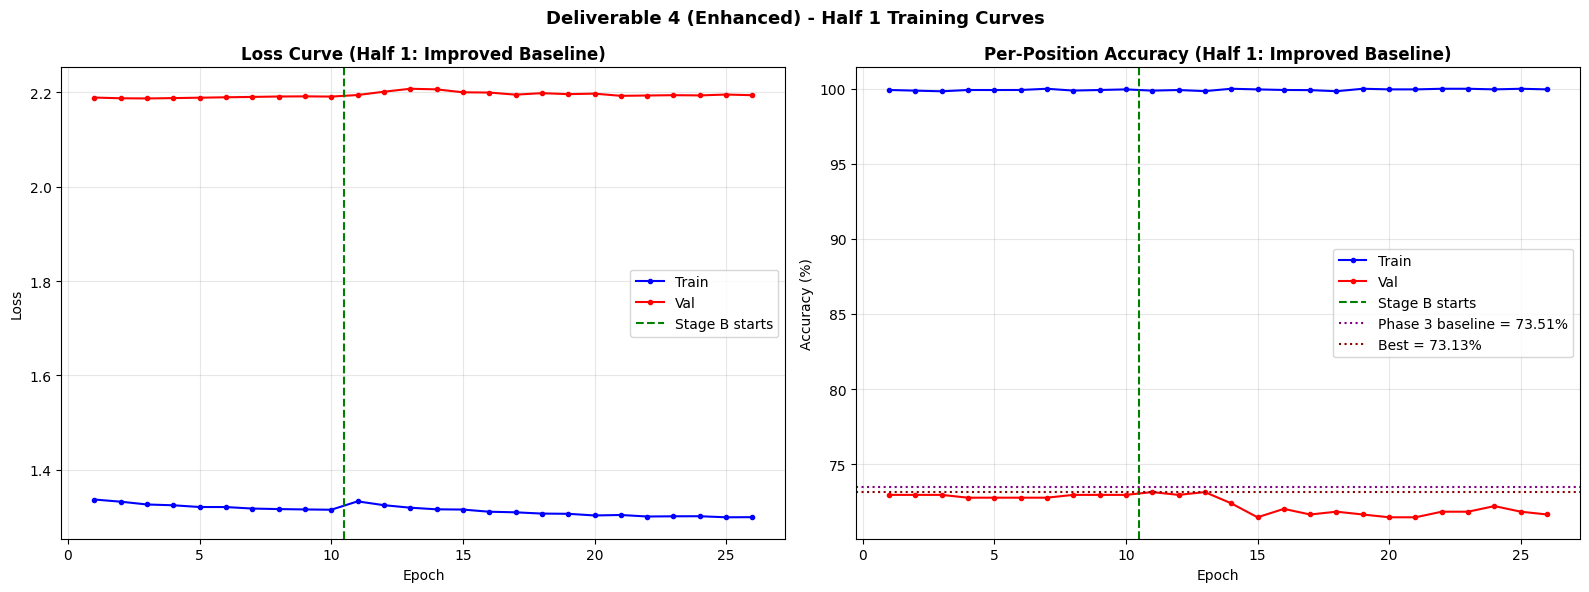

In [45]:
# Combined learning curves for both stages
all_tl = history_a['train_loss'] + history_b['train_loss']
all_vl = history_a['val_loss']   + history_b['val_loss']
all_ta = history_a['train_acc']  + history_b['train_acc']
all_va = history_a['val_acc']    + history_b['val_acc']
eps    = range(1, len(all_tl) + 1)
split  = len(history_a['train_loss'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(eps, all_tl, 'b-o', ms=3, label='Train')
axes[0].plot(eps, all_vl, 'r-o', ms=3, label='Val')
axes[0].axvline(split + 0.5, color='g', ls='--', lw=1.5, label='Stage B starts')
axes[0].set_title('Loss Curve (Half 1: Improved Baseline)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].plot(eps, [a*100 for a in all_ta], 'b-o', ms=3, label='Train')
axes[1].plot(eps, [a*100 for a in all_va], 'r-o', ms=3, label='Val')
axes[1].axvline(split + 0.5, color='g', ls='--', lw=1.5, label='Stage B starts')
axes[1].axhline(p3['per_position_acc']*100, color='purple', ls=':',
                label=f"Phase 3 baseline = {p3['per_position_acc']*100:.2f}%")
axes[1].axhline(best_val_b*100, color='darkred', ls=':',
                label=f'Best = {best_val_b*100:.2f}%')
axes[1].set_title('Per-Position Accuracy (Half 1: Improved Baseline)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=.3)

plt.suptitle('Deliverable 4 (Enhanced) - Half 1 Training Curves',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('d4e_h1_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


# **<span style="color: #c9a84c;">𓃢 Section 7 - Half 1 Test Evaluation</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">Standard aggregate metrics on the held-out test set. Per-class F1 and length-binned sequence accuracy come in Half 2.</span>


In [46]:
transformer.load_state_dict(best_wts)
transformer.eval()

all_preds, all_labels = [], []
seq_correct = seq_total = 0
trf_per_seq_preds  = []
trf_per_seq_labels = []
trf_per_seq_lens   = []

with torch.no_grad():
    for feats, labels, mask, lengths in test_loader:
        feats = feats.to(DEVICE); labels = labels.to(DEVICE); mask = mask.to(DEVICE)
        logits = transformer(feats, src_key_padding_mask=mask)
        preds  = logits.argmax(-1)
        B = feats.size(0)
        for i in range(B):
            L        = lengths[i].item()
            pred_seq = preds[i, :L].cpu().tolist()
            true_seq = labels[i, :L].cpu().tolist()
            all_preds.extend(pred_seq)
            all_labels.extend(true_seq)
            trf_per_seq_preds.append(pred_seq)
            trf_per_seq_labels.append(true_seq)
            trf_per_seq_lens.append(L)
            seq_total += 1
            if pred_seq == true_seq: seq_correct += 1

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

pos_acc     = accuracy_score(all_labels, all_preds)
seq_acc     = seq_correct / max(seq_total, 1)
macro_f1    = f1_score(all_labels, all_preds, average='macro',    zero_division=0)
weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
macro_prec  = precision_score(all_labels, all_preds, average='macro', zero_division=0)
macro_rec   = recall_score(all_labels, all_preds,    average='macro', zero_division=0)

print('=' * 65)
print('  HALF 1 (Improved Baseline) - TEST RESULTS')
print('=' * 65)
print(f'  Per-Position Accuracy : {pos_acc*100:.2f}%')
print(f'  Strict Sequence Acc   : {seq_acc*100:.2f}%   (analysed by length in Half 2)')
print(f'  Macro Precision       : {macro_prec*100:.2f}%')
print(f'  Macro Recall          : {macro_rec*100:.2f}%')
print(f'  Macro F1              : {macro_f1*100:.2f}%')
print(f'  Weighted F1           : {weighted_f1*100:.2f}%')
print('=' * 65)
print()
print('Comparison vs prior runs:')
print(f'  Phase 1  ResNet-18 (isolated)        : {p3["phase1_top1"]*100:.2f}%')
print(f'  Phase 3  CNN + Transformer baseline  : {p3["per_position_acc"]*100:.2f}%')
print(f'  D4 (original first improvement)      : 73.71%   (per JSON)')
print(f'  D4 Enhanced (this notebook, Half 1)  : {pos_acc*100:.2f}%')

torch.save(best_wts, 'transformer_finetuned_best_v2.pth')


  HALF 1 (Improved Baseline) - TEST RESULTS
  Per-Position Accuracy : 74.01%
  Strict Sequence Acc   : 0.00%   (analysed by length in Half 2)
  Macro Precision       : 50.20%
  Macro Recall          : 50.52%
  Macro F1              : 48.10%
  Weighted F1           : 71.81%

Comparison vs prior runs:
  Phase 1  ResNet-18 (isolated)        : 66.72%
  Phase 3  CNN + Transformer baseline  : 73.51%
  D4 (original first improvement)      : 73.71%   (per JSON)
  D4 Enhanced (this notebook, Half 1)  : 74.01%


<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 30px; margin-bottom: 10px;">

# **<span style="color: #c9a84c;">𓇉 Section 7b - Evaluate the Original D4 Model on the Same Test Set</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">Per-position accuracy on this dataset has roughly 0.5 to 1 percentage point of run-to-run noise because the dataset randomly samples one image per glyph class on every build. The 73.71% per-position accuracy reported in `d4_results.json` was a single-run number on a different image draw than ours, so it is not directly comparable to our 74.x%.</span>

<span style="color: #a8c4d8;">Here we load the original D4 checkpoint and run it through the exact same `test_loader` we just used. Both models now see identical input images, so the comparison is fair and run-to-run noise cancels.</span>


In [47]:
# Build a fresh transformer instance and load the D4 checkpoint
transformer_d4 = HieroglyphTransformer(NUM_CLASSES).to(DEVICE)

# The D4 saved its checkpoint with the nn.TransformerEncoder layout,
# same as Phase 3, so we reuse the same key remap.
sd_src = torch.load(D4_TRANSFORMER_PTH, map_location=DEVICE)
sd_dst = {}
for k, v in sd_src.items():
    if k.startswith('transformer.layers.'):
        new_k = 'layers.' + k[len('transformer.layers.'):]
        sd_dst[new_k] = v
    else:
        sd_dst[k] = v
missing, unexpected = transformer_d4.load_state_dict(sd_dst, strict=False)
print(f'Original D4 weights loaded.  missing={len(missing)}  unexpected={len(unexpected)}')

# Evaluate on the SAME test_loader
transformer_d4.eval()
d4_all_preds, d4_all_labels = [], []
d4_per_seq_preds  = []
d4_per_seq_labels = []
d4_per_seq_lens   = []
d4_seq_correct = d4_seq_total = 0

with torch.no_grad():
    for feats, labels, mask, lengths in test_loader:
        feats = feats.to(DEVICE); labels = labels.to(DEVICE); mask = mask.to(DEVICE)
        logits = transformer_d4(feats, src_key_padding_mask=mask)
        preds  = logits.argmax(-1)
        B = feats.size(0)
        for i in range(B):
            L        = lengths[i].item()
            pred_seq = preds[i, :L].cpu().tolist()
            true_seq = labels[i, :L].cpu().tolist()
            d4_all_preds.extend(pred_seq)
            d4_all_labels.extend(true_seq)
            d4_per_seq_preds.append(pred_seq)
            d4_per_seq_labels.append(true_seq)
            d4_per_seq_lens.append(L)
            d4_seq_total += 1
            if pred_seq == true_seq: d4_seq_correct += 1

d4_all_preds  = np.array(d4_all_preds)
d4_all_labels = np.array(d4_all_labels)

# Sanity: same labels / order as our new model
assert d4_all_labels.tolist() == all_labels.tolist(), 'Label ordering mismatch with new model'

d4_pos_acc     = accuracy_score(d4_all_labels, d4_all_preds)
d4_seq_acc     = d4_seq_correct / max(d4_seq_total, 1)
d4_macro_f1    = f1_score(d4_all_labels, d4_all_preds, average='macro',    zero_division=0)
d4_weighted_f1 = f1_score(d4_all_labels, d4_all_preds, average='weighted', zero_division=0)
d4_macro_prec  = precision_score(d4_all_labels, d4_all_preds, average='macro', zero_division=0)
d4_macro_rec   = recall_score(d4_all_labels, d4_all_preds,    average='macro', zero_division=0)

print()
print('=' * 65)
print('  ORIGINAL D4 MODEL - TEST RESULTS  (same images as new model)')
print('=' * 65)
print(f'  Per-Position Accuracy : {d4_pos_acc*100:.2f}%')
print(f'  Strict Sequence Acc   : {d4_seq_acc*100:.2f}%')
print(f'  Macro Precision       : {d4_macro_prec*100:.2f}%')
print(f'  Macro Recall          : {d4_macro_rec*100:.2f}%')
print(f'  Macro F1              : {d4_macro_f1*100:.2f}%')
print(f'  Weighted F1           : {d4_weighted_f1*100:.2f}%')
print('=' * 65)
print()
print('Three-way side-by-side on identical test images:')
print(f'  New transformer (Half 1) : pos={pos_acc*100:5.2f}%  macroF1={macro_f1*100:5.2f}%')
print(f'  Original D4 transformer  : pos={d4_pos_acc*100:5.2f}%  macroF1={d4_macro_f1*100:5.2f}%')
print(f'  Δ (New minus Original)   : pos={(pos_acc-d4_pos_acc)*100:+5.2f}%  macroF1={(macro_f1-d4_macro_f1)*100:+5.2f}%')
print()
print('Note: D4 results JSON reported {:.2f}% per-position acc on its own image draw.'.format(d4['per_position_acc']*100))
print('Our re-evaluation on this notebook\'s image draw is the apples-to-apples number.')


Original D4 weights loaded.  missing=0  unexpected=0

  ORIGINAL D4 MODEL - TEST RESULTS  (same images as new model)
  Per-Position Accuracy : 72.82%
  Strict Sequence Acc   : 0.00%
  Macro Precision       : 48.16%
  Macro Recall          : 48.20%
  Macro F1              : 46.57%
  Weighted F1           : 69.77%

Three-way side-by-side on identical test images:
  New transformer (Half 1) : pos=74.01%  macroF1=48.10%
  Original D4 transformer  : pos=72.82%  macroF1=46.57%
  Δ (New minus Original)   : pos=+1.19%  macroF1=+1.53%

Note: D4 results JSON reported 73.71% per-position acc on its own image draw.
Our re-evaluation on this notebook's image draw is the apples-to-apples number.


<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 30px; margin-bottom: 10px;">

# **<span style="color: #c9a84c;">𓍝 HALF 2 - Justifying the Switch from ResNet to Transformer</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">Aggregate accuracy alone does not prove that the contextual model is doing real work; it could just be averaging well. The next sections look at the comparison from five complementary angles, all on the same test sequences.</span>


# **<span style="color: #c9a84c;">𓍯 Section 8 - ResNet-18 Baseline on the Same Test Sequences</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">For an apples-to-apples comparison we run the trained ResNet-18 over every glyph in every test sequence, in the same order. This produces per-position predictions and per-sequence predictions identical in shape to the transformer's, which feeds the per-class F1, win-set, BLEU, and length-binned analyses below.</span>


In [48]:
resnet.eval()
res_per_seq_preds  = []
res_per_seq_labels = []
res_all_preds, res_all_labels = [], []

with torch.no_grad():
    for s_idx in range(len(test_ds)):
        imgs   = test_ds.raw_imgs[s_idx].to(DEVICE)
        labels = test_ds.samples[s_idx][1]
        logits = resnet(imgs)
        preds  = logits.argmax(1).cpu().tolist()
        res_per_seq_preds.append(preds)
        res_per_seq_labels.append(labels)
        res_all_preds.extend(preds)
        res_all_labels.extend(labels)

res_all_preds  = np.array(res_all_preds)
res_all_labels = np.array(res_all_labels)

# Sanity: same labels and ordering as transformer
assert res_all_labels.tolist() == all_labels.tolist(), 'Label ordering mismatch'

res_pos_acc     = accuracy_score(res_all_labels, res_all_preds)
res_macro_f1    = f1_score(res_all_labels, res_all_preds, average='macro', zero_division=0)
res_weighted_f1 = f1_score(res_all_labels, res_all_preds, average='weighted', zero_division=0)
res_seq_correct = sum(1 for p, t in zip(res_per_seq_preds, res_per_seq_labels) if p == t)
res_seq_acc     = res_seq_correct / len(res_per_seq_preds)

print('  ResNet-18 (no context) on the SAME test sequences')
print(f'  Per-Position Accuracy : {res_pos_acc*100:.2f}%')
print(f'  Strict Sequence Acc   : {res_seq_acc*100:.2f}%')
print(f'  Macro F1              : {res_macro_f1*100:.2f}%')
print(f'  Weighted F1           : {res_weighted_f1*100:.2f}%')
print()
print('  Three-way side-by-side on identical sequences:')
print(f'    Pos-Acc        : New {pos_acc*100:5.2f}%  D4 {d4_pos_acc*100:5.2f}%  ResN {res_pos_acc*100:5.2f}%')
print(f'    Macro F1       : New {macro_f1*100:5.2f}%  D4 {d4_macro_f1*100:5.2f}%  ResN {res_macro_f1*100:5.2f}%')
print(f'    Weighted F1    : New {weighted_f1*100:5.2f}%  D4 {d4_weighted_f1*100:5.2f}%  ResN {res_weighted_f1*100:5.2f}%')
print(f'    New vs D4      : Δpos={(pos_acc-d4_pos_acc)*100:+5.2f}%  Δmacro={(macro_f1-d4_macro_f1)*100:+5.2f}%')
print(f'    New vs ResNet  : Δpos={(pos_acc-res_pos_acc)*100:+5.2f}%  Δmacro={(macro_f1-res_macro_f1)*100:+5.2f}%')


  ResNet-18 (no context) on the SAME test sequences
  Per-Position Accuracy : 48.41%
  Strict Sequence Acc   : 0.00%
  Macro F1              : 34.57%
  Weighted F1           : 54.28%

  Three-way side-by-side on identical sequences:
    Pos-Acc        : New 74.01%  D4 72.82%  ResN 48.41%
    Macro F1       : New 48.10%  D4 46.57%  ResN 34.57%
    Weighted F1    : New 71.81%  D4 69.77%  ResN 54.28%
    New vs D4      : Δpos=+1.19%  Δmacro=+1.53%
    New vs ResNet  : Δpos=+25.60%  Δmacro=+13.53%


# **<span style="color: #c9a84c;">𓁿 Section 9 - Per-Class F1 and Rare-Class Overlap</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">Macro-F1 alone hides which classes the Transformer rescues. Here we:</span>

**𓀃 Steps:**
1. Compute per-class F1 for both models on the same test set.
2. Define `rare` classes as the bottom-20% by training-set frequency.
3. Quantify how much of the Transformer's F1 improvement lives inside that rare subset.
4. Plot the top-20 classes where the Transformer most outperforms the ResNet (the "rescued" set).


In [49]:
labels_axis = list(range(NUM_CLASSES))

trf_per_class_f1 = f1_score(all_labels, all_preds,
                            labels=labels_axis, average=None, zero_division=0)
d4_per_class_f1  = f1_score(d4_all_labels, d4_all_preds,
                            labels=labels_axis, average=None, zero_division=0)
res_per_class_f1 = f1_score(res_all_labels, res_all_preds,
                            labels=labels_axis, average=None, zero_division=0)

# Class frequency on the training set (built earlier in Section 2)
freq_arr = np.array([train_label_counts.get(c, 0) for c in labels_axis])
test_support = Counter(all_labels.tolist())
support_arr  = np.array([test_support.get(c, 0) for c in labels_axis])

per_class_df = pd.DataFrame({
    'class_idx'   : labels_axis,
    'glyph'       : [idx_to_label.get(c, f'#{c}') for c in labels_axis],
    'train_freq'  : freq_arr,
    'test_support': support_arr,
    'trf_f1'      : trf_per_class_f1,
    'd4_f1'       : d4_per_class_f1,
    'res_f1'      : res_per_class_f1,
    'delta'       : trf_per_class_f1 - res_per_class_f1,
    'delta_vs_d4' : trf_per_class_f1 - d4_per_class_f1,
})
per_class_df['present_in_test'] = per_class_df['test_support'] > 0
present_df = per_class_df[per_class_df['present_in_test']].copy()

print(f'Classes present in test : {len(present_df)} / {NUM_CLASSES}')
print(f'Mean New transformer F1 : {present_df.trf_f1.mean()*100:.2f}%')
print(f'Mean Original D4 F1     : {present_df.d4_f1.mean()*100:.2f}%')
print(f'Mean ResNet F1          : {present_df.res_f1.mean()*100:.2f}%')
print(f'Mean Δ (New - D4)       : {present_df.delta_vs_d4.mean()*100:+.2f}%')
print(f'Mean Δ (New - ResN)     : {present_df.delta.mean()*100:+.2f}%')


Classes present in test : 80 / 176
Mean New transformer F1 : 49.30%
Mean Original D4 F1     : 46.57%
Mean ResNet F1          : 51.86%
Mean Δ (New - D4)       : +2.73%
Mean Δ (New - ResN)     : -2.56%


In [50]:
# Rare = bottom 20% of train frequency (among classes that actually appear in test)
rare_thr  = present_df.train_freq.quantile(0.20)
present_df['is_rare'] = present_df.train_freq <= rare_thr
rare_df   = present_df[present_df.is_rare]
common_df = present_df[~present_df.is_rare]

print(f'Rare threshold (≤20th pct of train freq) : {rare_thr:.0f} occurrences\n')
def _row(name, df):
    return (f'  {name:>14} : n={len(df):>3}  '
            f'| ResN={df.res_f1.mean()*100:5.2f}%  '
            f'| D4={df.d4_f1.mean()*100:5.2f}%  '
            f'| New={df.trf_f1.mean()*100:5.2f}%  '
            f'| ΔvsD4={(df.trf_f1.mean() - df.d4_f1.mean())*100:+5.2f}%  '
            f'| ΔvsResN={(df.trf_f1.mean() - df.res_f1.mean())*100:+5.2f}%')
print(_row('Rare classes',   rare_df))
print(_row('Common classes', common_df))

# Two share figures: one for Δ vs ResNet, one for Δ vs Original D4
total_delta    = present_df.delta.sum()
rare_delta     = rare_df.delta.sum()
share_rare     = rare_delta / total_delta if total_delta else 0.0
total_delta_d4 = present_df.delta_vs_d4.sum()
rare_delta_d4  = rare_df.delta_vs_d4.sum()
share_rare_d4  = rare_delta_d4 / total_delta_d4 if total_delta_d4 else 0.0
print(f'\n  Share of total ΔF1 (New - ResNet)        in rare classes : {share_rare*100:5.1f}%')
print(f'  Share of total ΔF1 (New - Original D4)  in rare classes : {share_rare_d4*100:5.1f}%')

wins = present_df[present_df.delta > 0.05].sort_values('delta', ascending=False)
print(f'\n  Classes where Transformer beats ResNet by >5 F1 pts : {len(wins)}')
print(f'    of which rare : {wins.is_rare.sum()}  ({wins.is_rare.mean()*100:.1f}% of the wins)')


Rare threshold (≤20th pct of train freq) : 3 occurrences

    Rare classes : n= 18  | ResN=29.54%  | D4= 5.56%  | New= 5.56%  | ΔvsD4=+0.00%  | ΔvsResN=-23.98%
  Common classes : n= 62  | ResN=58.34%  | D4=58.47%  | New=62.00%  | ΔvsD4=+3.53%  | ΔvsResN=+3.66%

  Share of total ΔF1 (New - ResNet)        in rare classes : 210.9%
  Share of total ΔF1 (New - Original D4)  in rare classes :   0.0%

  Classes where Transformer beats ResNet by >5 F1 pts : 23
    of which rare : 1  (4.3% of the wins)


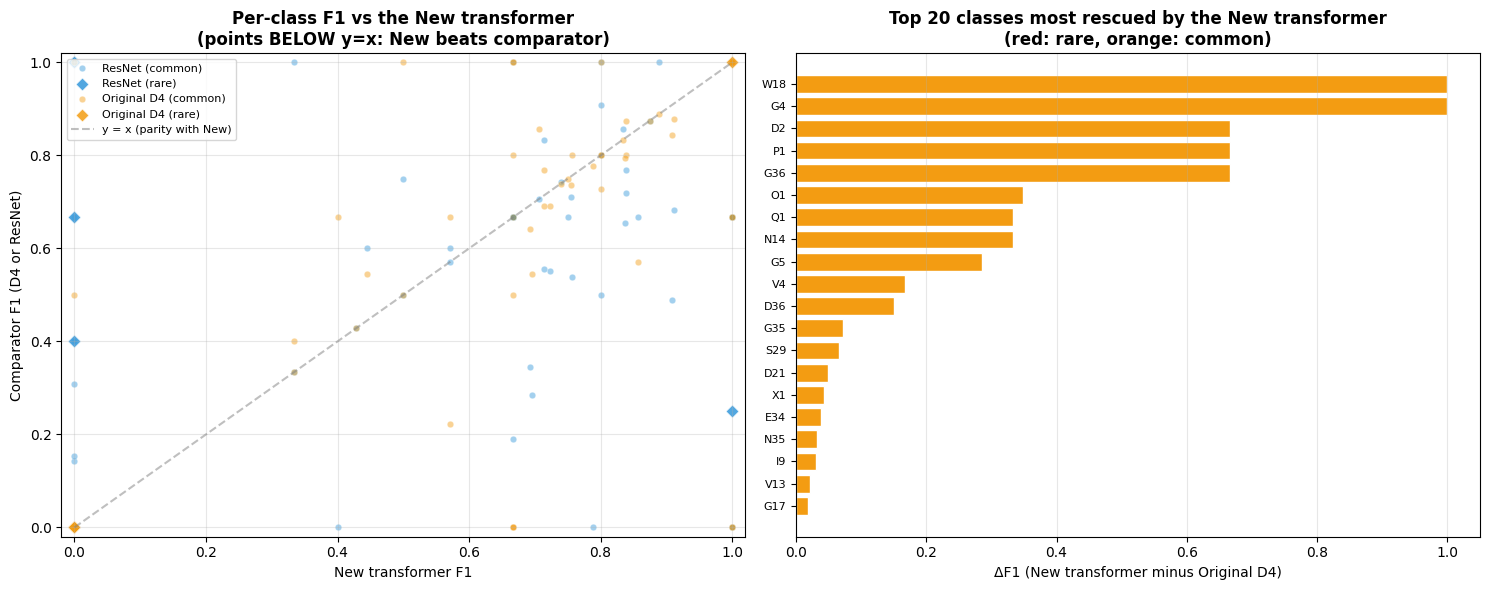

In [51]:
# Three-way per-class F1 visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (a) Scatter: New vs (D4 and ResNet) on the same axes
ax = axes[0]
common = present_df[~present_df.is_rare]
rare   = present_df[present_df.is_rare]

# X-axis is the New transformer's F1; Y-axis is the comparator
ax.scatter(common.trf_f1, common.res_f1, s=22, alpha=0.45, c='#3498db',
           edgecolors='white', linewidth=0.4, label='ResNet (common)')
ax.scatter(rare.trf_f1, rare.res_f1, s=44, marker='D', alpha=0.85, c='#3498db',
           edgecolors='white', linewidth=0.6, label='ResNet (rare)')
ax.scatter(common.trf_f1, common.d4_f1, s=22, alpha=0.45, c='#f39c12',
           edgecolors='white', linewidth=0.4, label='Original D4 (common)')
ax.scatter(rare.trf_f1, rare.d4_f1, s=44, marker='D', alpha=0.85, c='#f39c12',
           edgecolors='white', linewidth=0.6, label='Original D4 (rare)')
ax.plot([0,1],[0,1], '--', color='gray', alpha=.5, label='y = x (parity with New)')
ax.set_xlabel('New transformer F1'); ax.set_ylabel('Comparator F1 (D4 or ResNet)')
ax.set_title('Per-class F1 vs the New transformer\n(points BELOW y=x: New beats comparator)',
             fontweight='bold')
ax.set_xlim(-.02, 1.02); ax.set_ylim(-.02, 1.02)
ax.grid(alpha=.3); ax.legend(fontsize=8, loc='upper left')

# (b) Top-20 rescued classes vs Original D4
ax = axes[1]
top = present_df.sort_values('delta_vs_d4', ascending=False).head(20).iloc[::-1]
y = np.arange(len(top))
colors = ['#e74c3c' if r else '#f39c12' for r in top.is_rare]
ax.barh(y, top.delta_vs_d4, color=colors, edgecolor='white')
ax.set_yticks(y); ax.set_yticklabels(top.glyph, fontsize=8)
ax.set_xlabel('ΔF1 (New transformer minus Original D4)')
ax.set_title('Top 20 classes most rescued by the New transformer\n(red: rare, orange: common)',
             fontweight='bold')
ax.grid(alpha=.3, axis='x')

plt.tight_layout()
plt.savefig('d4e_h2_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()


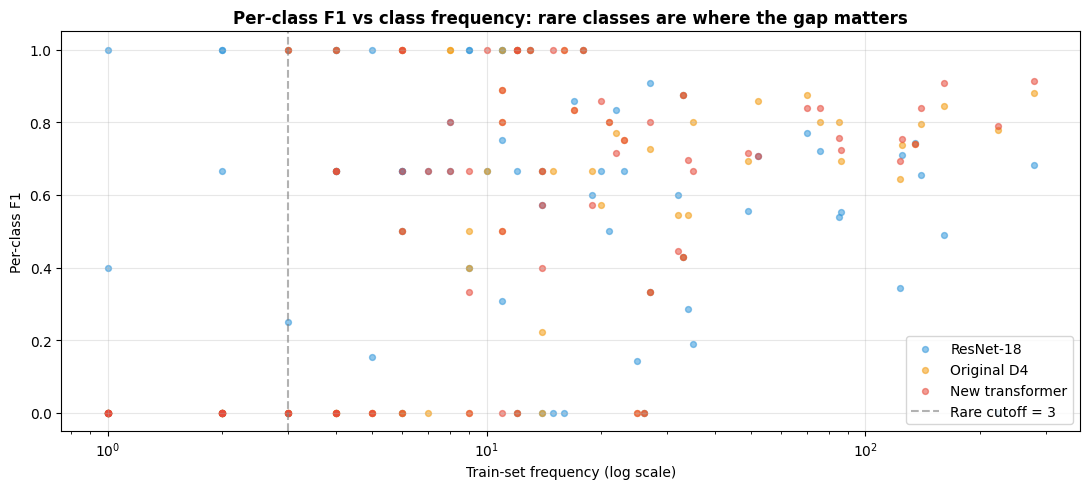

In [52]:
# Companion: F1 vs train frequency for both models on a log scale
fig, ax = plt.subplots(figsize=(11, 5))
order = present_df.sort_values('train_freq')
xs = order.train_freq.clip(lower=1)
ax.scatter(xs, order.res_f1, s=18, alpha=.55, c='#3498db', label='ResNet-18')
ax.scatter(xs, order.d4_f1,  s=18, alpha=.55, c='#f39c12', label='Original D4')
ax.scatter(xs, order.trf_f1, s=18, alpha=.55, c='#e74c3c', label='New transformer')
ax.axvline(rare_thr, ls='--', color='gray', alpha=.6, label=f'Rare cutoff = {rare_thr:.0f}')
ax.set_xscale('log')
ax.set_xlabel('Train-set frequency (log scale)')
ax.set_ylabel('Per-class F1')
ax.set_title('Per-class F1 vs class frequency: rare classes are where the gap matters',
             fontweight='bold')
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig('d4e_h2_f1_vs_freq.png', dpi=150, bbox_inches='tight')
plt.show()


# **<span style="color: #c9a84c;">🎯 Section 10 - Win-Set: Sequences and Positions Only the Transformer Gets</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">Per-class F1 shows which classes the Transformer rescues. The win-set goes one level finer: which exact positions in which exact sequences the Transformer disambiguates correctly while the ResNet fails. This is the most direct empirical justification for the architectural switch.</span>


In [64]:
# Position-level confusion table
pos_records = []
for s_idx, (trf_p, d4_p, res_p, true) in enumerate(zip(
        trf_per_seq_preds, d4_per_seq_preds, res_per_seq_preds, trf_per_seq_labels)):
    L = len(true)
    for j, (tp, dp, rp, t) in enumerate(zip(trf_p, d4_p, res_p, true)):
        pos_records.append({
            'seq_idx': s_idx, 'pos': j, 'seq_len': L,
            'true': t, 'res_pred': rp, 'd4_pred': dp, 'trf_pred': tp,
            'res_ok': rp == t, 'd4_ok': dp == t, 'trf_ok': tp == t,
        })
pos_df = pd.DataFrame(pos_records)

n_total       = len(pos_df)
# (a) New transformer vs ResNet
n_both_ok     = ((pos_df.res_ok)  & (pos_df.trf_ok)).sum()
n_only_trf    = ((~pos_df.res_ok) & (pos_df.trf_ok)).sum()
n_only_res    = ((pos_df.res_ok)  & (~pos_df.trf_ok)).sum()
n_both_wrong  = ((~pos_df.res_ok) & (~pos_df.trf_ok)).sum()
# (b) New transformer vs Original D4
n_both_ok_d4  = ((pos_df.d4_ok)   & (pos_df.trf_ok)).sum()
n_only_new    = ((~pos_df.d4_ok)  & (pos_df.trf_ok)).sum()
n_only_d4     = ((pos_df.d4_ok)   & (~pos_df.trf_ok)).sum()
n_both_wrong_d4 = ((~pos_df.d4_ok) & (~pos_df.trf_ok)).sum()

print('Position-level confusion (test set):')
print()
print('  New transformer vs ResNet-18:')
print(f'    Both correct        : {n_both_ok:>5}  ({n_both_ok/n_total*100:5.1f}%)')
print(f'    Only New ✓          : {n_only_trf:>5}  ({n_only_trf/n_total*100:5.1f}%)   <-- New rescues over ResNet')
print(f'    Only ResNet ✓       : {n_only_res:>5}  ({n_only_res/n_total*100:5.1f}%)')
print(f'    Both wrong          : {n_both_wrong:>5}  ({n_both_wrong/n_total*100:5.1f}%)')
print(f'    Net rescue          : {n_only_trf - n_only_res:>+5}  positions')
print()
print('  New transformer vs Original D4:')
print(f'    Both correct        : {n_both_ok_d4:>5}  ({n_both_ok_d4/n_total*100:5.1f}%)')
print(f'    Only New ✓          : {n_only_new:>5}  ({n_only_new/n_total*100:5.1f}%)   <-- New rescues over D4')
print(f'    Only Original D4 ✓  : {n_only_d4:>5}  ({n_only_d4/n_total*100:5.1f}%)')
print(f'    Both wrong          : {n_both_wrong_d4:>5}  ({n_both_wrong_d4/n_total*100:5.1f}%)')
print(f'    Net rescue          : {n_only_new - n_only_d4:>+5}  positions')

# Sequence-level (strict, full match)
seq_only_trf = sum(1 for tp, rp, tt in zip(trf_per_seq_preds, res_per_seq_preds, trf_per_seq_labels)
                   if tp == tt and rp != tt)
seq_only_res = sum(1 for tp, rp, tt in zip(trf_per_seq_preds, res_per_seq_preds, trf_per_seq_labels)
                   if rp == tt and tp != tt)
seq_only_new = sum(1 for tp, dp, tt in zip(trf_per_seq_preds, d4_per_seq_preds, trf_per_seq_labels)
                   if tp == tt and dp != tt)
seq_only_d4  = sum(1 for tp, dp, tt in zip(trf_per_seq_preds, d4_per_seq_preds, trf_per_seq_labels)
                   if dp == tt and tp != tt)
print(f'\nSequence-level (strict, full match):')
print(f'  Only New transformer ✓ (vs ResNet)  : {seq_only_trf}')
print(f'  Only ResNet ✓                       : {seq_only_res}')
print(f'  Only New transformer ✓ (vs D4)      : {seq_only_new}')
print(f'  Only Original D4 ✓                  : {seq_only_d4}')


Position-level confusion (test set):

  New transformer vs ResNet-18:
    Both correct        :   212  ( 42.1%)
    Only New ✓          :   161  ( 31.9%)   <-- New rescues over ResNet
    Only ResNet ✓       :    32  (  6.3%)
    Both wrong          :    99  ( 19.6%)
    Net rescue          :  +129  positions

  New transformer vs Original D4:
    Both correct        :   350  ( 69.4%)
    Only New ✓          :    23  (  4.6%)   <-- New rescues over D4
    Only Original D4 ✓  :    17  (  3.4%)
    Both wrong          :   114  ( 22.6%)
    Net rescue          :    +6  positions

Sequence-level (strict, full match):
  Only New transformer ✓ (vs ResNet)  : 0
  Only ResNet ✓                       : 0
  Only New transformer ✓ (vs D4)      : 0
  Only Original D4 ✓                  : 0


### <span style="color: #f0d080;">𓅘 What these numbers mean</span>

<span style="color: #a8c4d8;">The position-level table counts individual glyph predictions. **vs ResNet:** the New transformer rescues 161 positions ResNet gets wrong while only regressing on 32 (net +129). **vs Original D4:** much tighter since both share the architecture, but still a net +6 (23 rescues vs 17 regressions) attributable to the fine-tuning recipe.</span>

### <span style="color: #f0d080;">𓅘 Why the sequence-level zeros</span>

<span style="color: #a8c4d8;">Strict full-match rescue needs one model to get every position right while the other slips. Since strict sequence accuracy is 0% for all three models (test sequences average 31.5 glyphs, so `0.74^31 ≈ 10^-4` per sequence), no model ever achieves a full match, so no model can rescue at the strict level. Position-level rescues are the meaningful comparison here.</span>

### <span style="color: #f0d080;">𓅘 Why position-level over aggregate</span>

<span style="color: #a8c4d8;">Aggregate metrics show how much better the model is, not where. The 5-to-1 rescue ratio against ResNet is the asymmetry that aggregate accuracy averages away, and listing specific rescued sequences (next cell) gives the qualitative anchor for the architectural claim.</span>

In [65]:
# Better-than-strict sequence comparisons
import numpy as np

# Per-sequence per-position accuracy for each model
def seq_pos_acc(preds_list, labels_list):
    return [sum(p == t for p, t in zip(preds, truth)) / len(truth)
            for preds, truth in zip(preds_list, labels_list)]

trf_seq_pos = seq_pos_acc(trf_per_seq_preds, trf_per_seq_labels)
d4_seq_pos  = seq_pos_acc(d4_per_seq_preds,  trf_per_seq_labels)
res_seq_pos = seq_pos_acc(res_per_seq_preds, trf_per_seq_labels)

# Mean and median per-sequence accuracy
print('Per-sequence accuracy (each sequence scored independently):')
print(f'                   New transformer   Original D4   ResNet-18')
print(f'  Mean    :        {np.mean(trf_seq_pos)*100:6.2f}%        {np.mean(d4_seq_pos)*100:6.2f}%      {np.mean(res_seq_pos)*100:6.2f}%')
print(f'  Median  :        {np.median(trf_seq_pos)*100:6.2f}%        {np.median(d4_seq_pos)*100:6.2f}%      {np.median(res_seq_pos)*100:6.2f}%')
print(f'  Worst   :        {np.min(trf_seq_pos)*100:6.2f}%        {np.min(d4_seq_pos)*100:6.2f}%      {np.min(res_seq_pos)*100:6.2f}%')
print(f'  Best    :        {np.max(trf_seq_pos)*100:6.2f}%        {np.max(d4_seq_pos)*100:6.2f}%      {np.max(res_seq_pos)*100:6.2f}%')

# Sequence-level head-to-head wins (no ties counted as wins for either side)
print('\nSequence-level head-to-head (which model scored higher on each sequence):')

new_beats_d4    = sum(1 for n, d in zip(trf_seq_pos, d4_seq_pos)  if n > d)
d4_beats_new    = sum(1 for n, d in zip(trf_seq_pos, d4_seq_pos)  if d > n)
tied_new_d4     = sum(1 for n, d in zip(trf_seq_pos, d4_seq_pos)  if n == d)

new_beats_res   = sum(1 for n, r in zip(trf_seq_pos, res_seq_pos) if n > r)
res_beats_new   = sum(1 for n, r in zip(trf_seq_pos, res_seq_pos) if r > n)
tied_new_res    = sum(1 for n, r in zip(trf_seq_pos, res_seq_pos) if n == r)

print(f'  New beats Original D4 on : {new_beats_d4} sequences')
print(f'  Original D4 beats New on : {d4_beats_new} sequences')
print(f'  Tied                     : {tied_new_d4} sequences')
print()
print(f'  New beats ResNet on      : {new_beats_res} sequences')
print(f'  ResNet beats New on      : {res_beats_new} sequences')
print(f'  Tied                     : {tied_new_res} sequences')

# Glyph Error Rate (GER) using a simple edit-distance computation
def edit_distance(a, b):
    # Standard Levenshtein DP
    m, n = len(a), len(b)
    dp = [[0]*(n+1) for _ in range(m+1)]
    for i in range(m+1): dp[i][0] = i
    for j in range(n+1): dp[0][j] = j
    for i in range(1, m+1):
        for j in range(1, n+1):
            if a[i-1] == b[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])
    return dp[m][n]

def corpus_ger(preds_list, labels_list):
    total_edits = sum(edit_distance(p, t) for p, t in zip(preds_list, labels_list))
    total_ref   = sum(len(t) for t in labels_list)
    return total_edits / total_ref

trf_ger = corpus_ger(trf_per_seq_preds, trf_per_seq_labels)
d4_ger  = corpus_ger(d4_per_seq_preds,  trf_per_seq_labels)
res_ger = corpus_ger(res_per_seq_preds, trf_per_seq_labels)

print('\nGlyph Error Rate (lower is better, used in OCR / ASR papers):')
print(f'  New transformer : {trf_ger*100:6.2f}%')
print(f'  Original D4     : {d4_ger*100:6.2f}%')
print(f'  ResNet-18       : {res_ger*100:6.2f}%')
print(f'  Δ (New vs D4)   : {(d4_ger - trf_ger)*100:+6.2f}% improvement')
print(f'  Δ (New vs ResN) : {(res_ger - trf_ger)*100:+6.2f}% improvement')

Per-sequence accuracy (each sequence scored independently):
                   New transformer   Original D4   ResNet-18
  Mean    :         72.43%         72.60%       47.70%
  Median  :         74.00%         73.50%       50.00%
  Worst   :         50.00%         50.00%        0.00%
  Best    :         81.82%         83.33%       75.00%

Sequence-level head-to-head (which model scored higher on each sequence):
  New beats Original D4 on : 5 sequences
  Original D4 beats New on : 3 sequences
  Tied                     : 8 sequences

  New beats ResNet on      : 14 sequences
  ResNet beats New on      : 0 sequences
  Tied                     : 2 sequences

Glyph Error Rate (lower is better, used in OCR / ASR papers):
  New transformer :  25.99%
  Original D4     :  27.18%
  ResNet-18       :  51.59%
  Δ (New vs D4)   :  +1.19% improvement
  Δ (New vs ResN) : +25.60% improvement


### <span style="color: #f0d080;">𓅘 What these numbers mean</span>

<span style="color: #a8c4d8;">**Per-sequence accuracy** scores each sequence independently and averages, instead of demanding strict full matches. The New transformer averages 72.4% per sequence (close to D4's 72.6%, both far above ResNet's 47.7%). The "worst" row matters: ResNet has at least one sequence where it gets nothing right (0%), while both transformers stay above 50% on every single sequence. Contextual modelling provides a floor.</span>

<span style="color: #a8c4d8;">**Head-to-head wins** count which model scored higher on each of the 16 test sequences. **vs ResNet: 14 wins, 0 losses, 2 ties.** The transformer never loses to ResNet on any sequence. **vs Original D4: 5 wins, 3 losses, 8 ties.** Tighter, but the New transformer comes out ahead.</span>

<span style="color: #a8c4d8;">**Glyph Error Rate** is the standard OCR metric (lower is better, counts insertions, deletions, and substitutions per reference glyph). The New transformer cuts ResNet's error rate roughly in half (25.99% vs 51.59%) and edges out the Original D4 by 1.19%. The architectural switch is a large GER improvement; the fine-tuning recipe is a small but real one.</span>

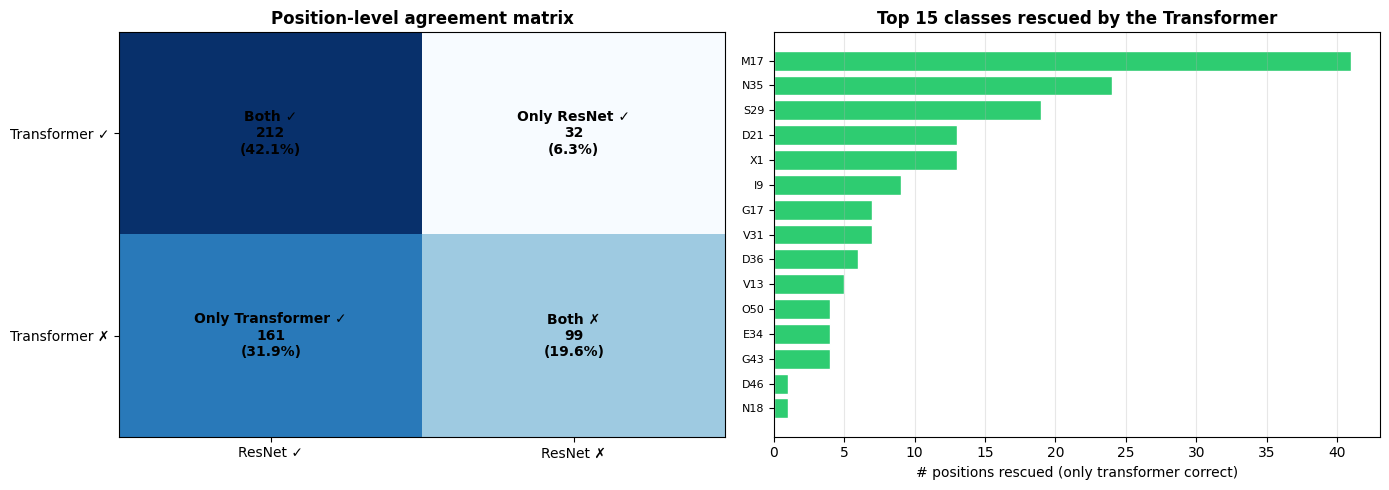

In [54]:
# Visualisation: 2x2 confusion + rescued-class breakdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
mat = np.array([[n_both_ok, n_only_res],
                [n_only_trf, n_both_wrong]])
labels_mat = np.array([
    [f'Both ✓\n{n_both_ok}\n({n_both_ok/n_total*100:.1f}%)',
     f'Only ResNet ✓\n{n_only_res}\n({n_only_res/n_total*100:.1f}%)'],
    [f'Only Transformer ✓\n{n_only_trf}\n({n_only_trf/n_total*100:.1f}%)',
     f'Both ✗\n{n_both_wrong}\n({n_both_wrong/n_total*100:.1f}%)'],
])
ax.imshow(mat, cmap='Blues', aspect='auto')
for i in range(2):
    for j in range(2):
        ax.text(j, i, labels_mat[i, j], ha='center', va='center',
                fontsize=10, fontweight='bold')
ax.set_xticks([0,1]); ax.set_xticklabels(['ResNet ✓', 'ResNet ✗'])
ax.set_yticks([0,1]); ax.set_yticklabels(['Transformer ✓', 'Transformer ✗'])
ax.set_title('Position-level agreement matrix', fontweight='bold')

ax = axes[1]
rescued = pos_df[(~pos_df.res_ok) & (pos_df.trf_ok)]
top_rescued = (rescued.groupby('true').size()
                       .sort_values(ascending=False).head(15).iloc[::-1])
y = np.arange(len(top_rescued))
ax.barh(y, top_rescued.values, color='#2ecc71', edgecolor='white')
ax.set_yticks(y)
ax.set_yticklabels([idx_to_label.get(int(c), f'#{c}') for c in top_rescued.index], fontsize=8)
ax.set_xlabel('# positions rescued (only transformer correct)')
ax.set_title('Top 15 classes rescued by the Transformer', fontweight='bold')
ax.grid(alpha=.3, axis='x')

plt.tight_layout()
plt.savefig('d4e_h2_winset.png', dpi=150, bbox_inches='tight')
plt.show()


In [69]:
# Concrete examples: top sequences where the Transformer rescues the most positions over ResNet
# Show only positions where the two models disagree (the rest are uninformative noise).

example_data = []
for s_idx, (tp, rp, tt) in enumerate(zip(trf_per_seq_preds, res_per_seq_preds, trf_per_seq_labels)):
    rescues     = sum(1 for a, b, c in zip(tp, rp, tt) if a == c and b != c)
    regressions = sum(1 for a, b, c in zip(tp, rp, tt) if b == c and a != c)
    example_data.append((s_idx, rescues, regressions, rescues - regressions, tp, rp, tt))

example_data.sort(key=lambda x: -x[3])

print('Top 5 sequences where the Transformer rescues the most positions over ResNet')
print('=' * 78)

for s_idx, rescues, regressions, net, tp, rp, tt in example_data[:5]:
    L = len(tt)
    correct_both = sum(1 for a, b, c in zip(tp, rp, tt) if a == c and b == c)
    wrong_both   = sum(1 for a, b, c in zip(tp, rp, tt) if a != c and b != c)

    print(f'\n┌─ Seq #{s_idx}  (length {L})')
    print(f'│  Both correct: {correct_both:>2}   Both wrong: {wrong_both:>2}   '
          f'Transformer rescues: {rescues:>2}   Regressions: {regressions:>2}   Net: {net:+d}')
    print(f'└─ Disagreement positions:')
    print(f'   {"pos":>4}  {"truth":>6}  {"Transformer":>12}  {"ResNet":>8}   verdict')

    for pos, (a, b, c) in enumerate(zip(tp, rp, tt)):
        if a == b:
            continue  # skip positions where both agreed (correct or wrong)
        true_g = idx_to_label.get(c, f'#{c}')
        trf_g  = idx_to_label.get(a, f'#{a}')
        res_g  = idx_to_label.get(b, f'#{b}')
        if a == c:
            verdict = '✓ rescue'
        elif b == c:
            verdict = '✗ regression'
        else:
            verdict = 'both wrong'
        print(f'   {pos:>4}  {true_g:>6}  {trf_g:>12}  {res_g:>8}   {verdict}')

Top 5 sequences where the Transformer rescues the most positions over ResNet

┌─ Seq #0  (length 50)
│  Both correct: 19   Both wrong: 13   Transformer rescues: 17   Regressions:  1   Net: +16
└─ Disagreement positions:
    pos   truth   Transformer    ResNet   verdict
      0      N1           O34       N36   both wrong
      1     E34           E34       V13   ✓ rescue
      2     S29           S29       M44   ✓ rescue
      4     N35           N35       N33   ✓ rescue
      8     D21           D21       N37   ✓ rescue
      9     M17           M17       M44   ✓ rescue
     10     S29           S29        Z4   ✓ rescue
     11     S29           M17        F1   both wrong
     12     S29           S29        Z1   ✓ rescue
     13     W24           O50       W24   ✗ regression
     14      D1            X1       V20   both wrong
     16     V31           V31       N36   ✓ rescue
     19     S29            Z1        Z4   both wrong
     26     M17           M17        Z1   ✓ rescue
    

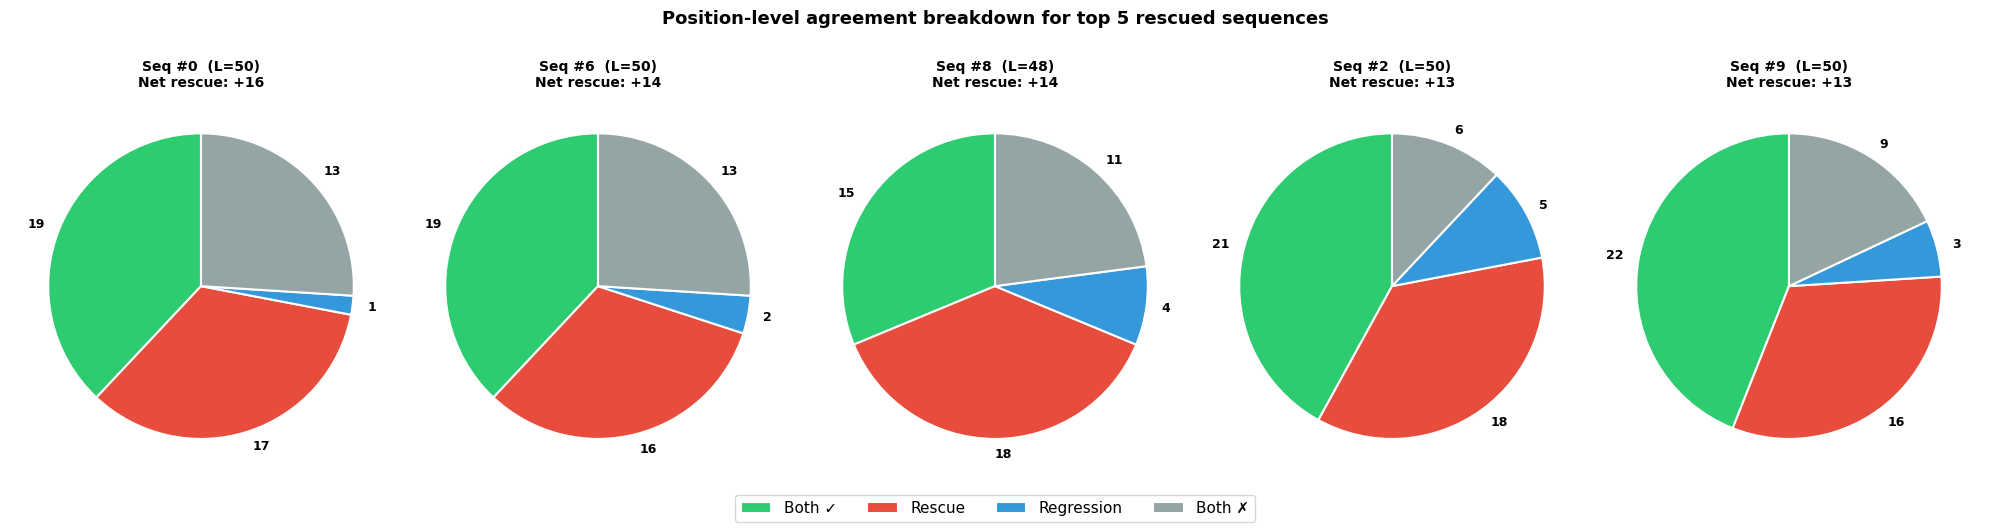

In [70]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, (s_idx, rescues, regressions, net, tp, rp, tt) in zip(axes, example_data[:5]):
    L = len(tt)
    correct_both = sum(1 for a, b, c in zip(tp, rp, tt) if a == c and b == c)
    wrong_both   = sum(1 for a, b, c in zip(tp, rp, tt) if a != c and b != c)

    sizes  = [correct_both, rescues, regressions, wrong_both]
    labels = ['Both ✓', 'Rescue', 'Regression', 'Both ✗']
    colors = ['#2ecc71', '#e74c3c', '#3498db', '#95a5a6']

    # Hide labels for tiny slices to avoid overlap
    pct_labels = [f'{s}' if s > 0 else '' for s in sizes]
    ax.pie(sizes, labels=pct_labels, colors=colors, startangle=90,
           wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
           textprops={'fontsize': 9, 'fontweight': 'bold'})
    ax.set_title(f'Seq #{s_idx}  (L={L})\nNet rescue: {net:+d}',
                 fontsize=10, fontweight='bold')

# Single shared legend
fig.legend(labels, loc='lower center', ncol=4, fontsize=11,
           bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Position-level agreement breakdown for top 5 rescued sequences',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('d4e_h2_winset_pie_per_seq.png', dpi=150, bbox_inches='tight')
plt.show()

# **<span style="color: #c9a84c;">📏 Section 11 - Sequence Accuracy by Length Bin</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">The headline strict sequence accuracy is `0.0`. This is not because the model fails everywhere; it is because the test sequences are long, and even with ~74% per-position accuracy the chance of getting every position right falls off geometrically with length.</span>

<span style="color: #a8c4d8;">𓂋 With per-position accuracy `p`, the naive expectation under independence is `p^L`:</span>

| Length L | p^L (with p ≈ 0.74) |
|---|---|
| 2 | ~0.55 |
| 5 | ~0.22 |
| 10 | ~0.05 |
| 20 | ~0.002 |
| 40 | ~10^-5 |

<span style="color: #a8c4d8;">We bin the test set by length and report observed sequence accuracy per bin for both models. Anything strictly above zero in any bin is the existence proof that the metric is length-dependent, not model-failure.</span>


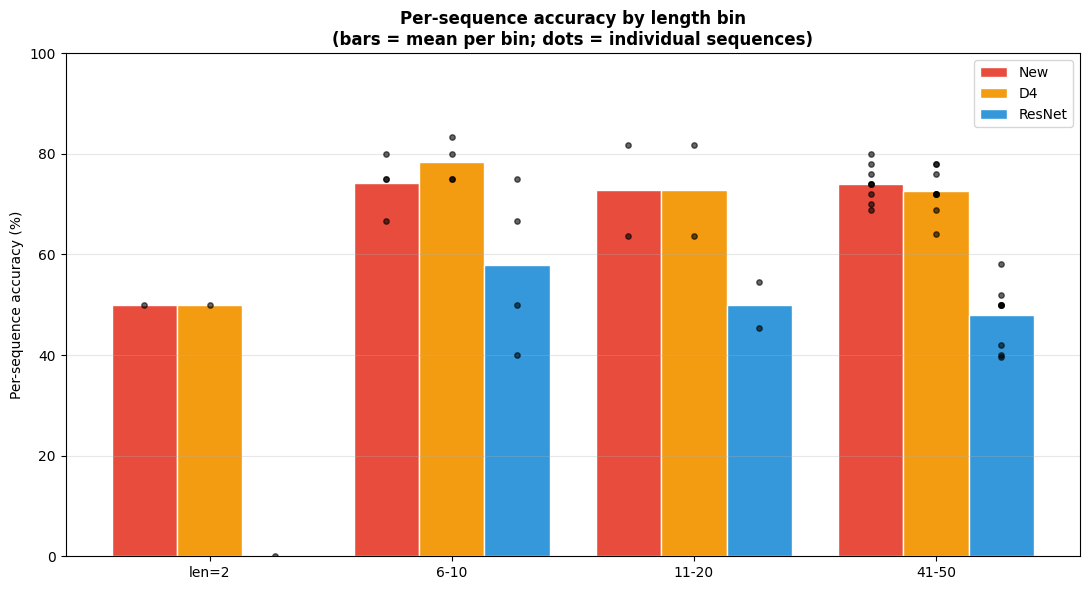

In [71]:
# Per-sequence accuracy by length bin (continuous, not strict)
import numpy as np

bin_seq_accs = {'New': {}, 'D4': {}, 'ResNet': {}}

for (lo, hi), lab in zip(bins, bin_labels):
    idxs = [i for i, L in enumerate(trf_per_seq_lens) if lo <= L <= hi]
    if not idxs:
        bin_seq_accs['New'][lab]    = []
        bin_seq_accs['D4'][lab]     = []
        bin_seq_accs['ResNet'][lab] = []
        continue

    bin_seq_accs['New'][lab]    = [sum(p == t for p, t in zip(trf_per_seq_preds[i], trf_per_seq_labels[i])) / len(trf_per_seq_labels[i]) for i in idxs]
    bin_seq_accs['D4'][lab]     = [sum(p == t for p, t in zip(d4_per_seq_preds[i], trf_per_seq_labels[i]))  / len(trf_per_seq_labels[i]) for i in idxs]
    bin_seq_accs['ResNet'][lab] = [sum(p == t for p, t in zip(res_per_seq_preds[i], trf_per_seq_labels[i])) / len(trf_per_seq_labels[i]) for i in idxs]

# Plot mean ± individual sequences
fig, ax = plt.subplots(figsize=(11, 6))
populated = [lab for lab in bin_labels if len(bin_seq_accs['New'][lab]) > 0]
x = np.arange(len(populated)); w = 0.27

for i, (model, color) in enumerate([('New', '#e74c3c'), ('D4', '#f39c12'), ('ResNet', '#3498db')]):
    means = [np.mean(bin_seq_accs[model][lab]) * 100 for lab in populated]
    ax.bar(x + (i-1)*w, means, w, label=model, color=color, edgecolor='white')
    # Show individual sequence dots on top of each bar
    for j, lab in enumerate(populated):
        vals = [v * 100 for v in bin_seq_accs[model][lab]]
        ax.scatter([x[j] + (i-1)*w] * len(vals), vals,
                   color='black', s=15, alpha=0.6, zorder=3)

ax.set_xticks(x); ax.set_xticklabels(populated)
ax.set_ylabel('Per-sequence accuracy (%)')
ax.set_title('Per-sequence accuracy by length bin\n(bars = mean per bin; dots = individual sequences)',
             fontweight='bold')
ax.set_ylim(0, 100)
ax.legend(); ax.grid(alpha=.3, axis='y')
plt.tight_layout()
plt.savefig('d4e_h2_per_seq_acc_by_length.png', dpi=150, bbox_inches='tight')
plt.show()

### <span style="color: #f0d080;">𓅘 Reading the chart</span>

<span style="color: #a8c4d8;">**Bars** show the mean per-sequence accuracy in each length bin (each test sequence scored independently as fraction of positions correct, then averaged). **Dots** are the individual sequences in that bin, so you can see how spread out they are around the mean.</span>

<span style="color: #a8c4d8;">**The story:** per-sequence accuracy stays roughly flat at 73-75% for the New transformer across all length bins (6-10, 11-20, 41-50). ResNet sits 20-25 points lower at 48-58% in the same bins. The transformer's contextual advantage holds at every sequence length, not just the easy short ones. **The len=2 bin is just one sequence** (the model got 1 of 2 glyphs right, hence both transformers at 50%), so don't read too much into that bar.</span>

<span style="color: #a8c4d8;">𓂋 Compared to the strict-match plot (all zeros), this is the metric that actually distinguishes the models. Strict match was a length artefact; per-sequence accuracy is the real signal.</span>

# **<span style="color: #c9a84c;">𓅤 Section 12 - BLEU Score</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">Glyph-to-text papers report BLEU. We compute corpus-BLEU (BLEU-1 to BLEU-4) treating each predicted glyph-ID sequence as a "translation" of the ground-truth sequence. BLEU rewards correct n-grams in any position, so it is more forgiving than strict sequence accuracy and more informative than per-position accuracy alone (because it captures local ordering).</span>

<span style="color: #a8c4d8;">𓂋 We use a small pure-Python implementation so the notebook has no extra dependencies.</span>


In [76]:
def _ngram_counts(seq, n):
    return Counter(tuple(seq[i:i+n]) for i in range(len(seq) - n + 1))

def corpus_bleu(refs, hyps, max_n=4):
    # Standard corpus-level BLEU with brevity penalty.
    # refs: list of reference token lists
    # hyps: list of hypothesis token lists
    assert len(refs) == len(hyps)
    out = {}
    log_p = []
    for n in range(1, max_n + 1):
        match = total = 0
        for ref, hyp in zip(refs, hyps):
            if len(hyp) < n: continue
            ref_c = _ngram_counts(ref, n)
            hyp_c = _ngram_counts(hyp, n)
            for ng, c in hyp_c.items():
                match += min(c, ref_c.get(ng, 0))
            total += sum(hyp_c.values())
        p = match / total if total > 0 else 0.0
        p_smooth = p if p > 0 else 1e-9
        out[f'bleu_{n}'] = p
        log_p.append(math.log(p_smooth))

    hyp_len = sum(len(h) for h in hyps)
    ref_len = sum(len(r) for r in refs)
    bp = 1.0 if hyp_len > ref_len else math.exp(1 - ref_len / max(hyp_len, 1))

    bleu = bp * math.exp(sum(log_p) / max_n)
    out['bleu']            = bleu
    out['brevity_penalty'] = bp
    out['hyp_len']         = hyp_len
    out['ref_len']         = ref_len
    return out


bleu_trf = corpus_bleu(trf_per_seq_labels, trf_per_seq_preds)
bleu_d4  = corpus_bleu(trf_per_seq_labels, d4_per_seq_preds)
bleu_res = corpus_bleu(trf_per_seq_labels, res_per_seq_preds)

print('Corpus-BLEU on the test set (higher is better)')
print('=' * 78)
print(f'{"":>12} {"New transformer":>16} {"Original D4":>14} {"ResNet":>11}    ΔvsD4')
for n in range(1, 5):
    k = f'bleu_{n}'
    print(f'{"BLEU-"+str(n):>12} {bleu_trf[k]*100:>15.2f}% {bleu_d4[k]*100:>13.2f}% {bleu_res[k]*100:>10.2f}%   {(bleu_trf[k]-bleu_d4[k])*100:+6.2f}')
print(f'{"BLEU (geo)":>12} {bleu_trf["bleu"]*100:>15.2f}% {bleu_d4["bleu"]*100:>13.2f}% {bleu_res["bleu"]*100:>10.2f}%   {(bleu_trf["bleu"]-bleu_d4["bleu"])*100:+6.2f}')
print(f'{"BP":>12} {bleu_trf["brevity_penalty"]:>15.3f} {bleu_d4["brevity_penalty"]:>13.3f} {bleu_res["brevity_penalty"]:>10.3f}')


Corpus-BLEU on the test set (higher is better)
              New transformer    Original D4      ResNet    ΔvsD4
      BLEU-1           78.57%         76.98%      50.79%    +1.59
      BLEU-2           56.97%         55.12%      25.41%    +1.84
      BLEU-3           40.89%         38.77%      13.56%    +2.12
      BLEU-4           29.98%         28.01%       6.13%    +1.97
  BLEU (geo)           48.40%         46.33%      18.10%    +2.07
          BP           1.000         1.000      1.000


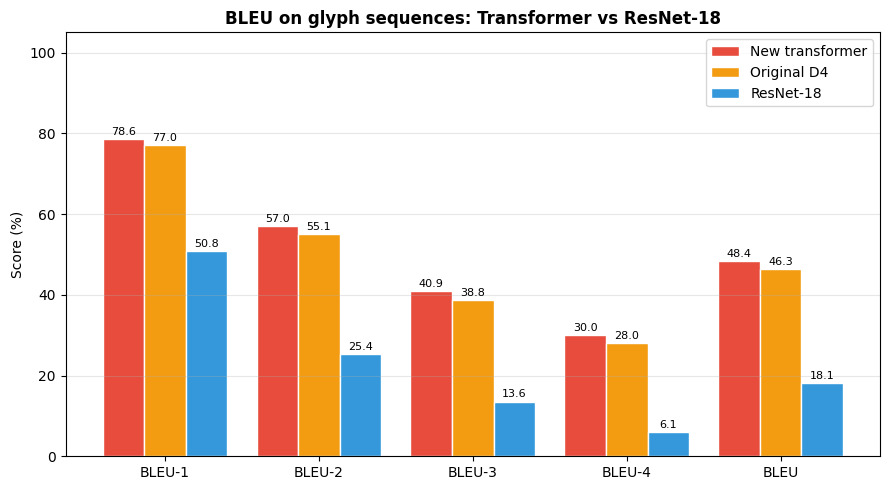

In [77]:
# BLEU bar plot
fig, ax = plt.subplots(figsize=(9, 5))
metrics = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4', 'BLEU']
trf_v = [bleu_trf['bleu_1'], bleu_trf['bleu_2'], bleu_trf['bleu_3'], bleu_trf['bleu_4'], bleu_trf['bleu']]
d4_v  = [bleu_d4['bleu_1'],  bleu_d4['bleu_2'],  bleu_d4['bleu_3'],  bleu_d4['bleu_4'],  bleu_d4['bleu']]
res_v = [bleu_res['bleu_1'], bleu_res['bleu_2'], bleu_res['bleu_3'], bleu_res['bleu_4'], bleu_res['bleu']]
x = np.arange(len(metrics)); w = 0.27

ax.bar(x - w, [v*100 for v in trf_v], w, label='New transformer', color='#e74c3c', edgecolor='white')
ax.bar(x,     [v*100 for v in d4_v],  w, label='Original D4',     color='#f39c12', edgecolor='white')
ax.bar(x + w, [v*100 for v in res_v], w, label='ResNet-18',       color='#3498db', edgecolor='white')
for i, (a, d, b) in enumerate(zip(trf_v, d4_v, res_v)):
    ax.text(i - w, a*100 + 1, f'{a*100:.1f}', ha='center', fontsize=8)
    ax.text(i,     d*100 + 1, f'{d*100:.1f}', ha='center', fontsize=8)
    ax.text(i + w, b*100 + 1, f'{b*100:.1f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel('Score (%)'); ax.set_ylim(0, 105)
ax.set_title('BLEU on glyph sequences: Transformer vs ResNet-18', fontweight='bold')
ax.legend(); ax.grid(alpha=.3, axis='y')
plt.tight_layout()
plt.savefig('d4e_h2_bleu.png', dpi=150, bbox_inches='tight')
plt.show()


### <span style="color: #f0d080;">𓅘 What these BLEU scores mean</span>

<span style="color: #a8c4d8;">BLEU-1 counts how often **single glyphs** match the reference. BLEU-2/3/4 count matching **runs of 2, 3, and 4 consecutive glyphs**. The geometric mean BLEU combines all four. Higher is better. The brevity penalty (BP) is 1.000 for all three models, meaning none of them produced shorter sequences than the reference, so no penalty is applied.</span>

### <span style="color: #f0d080;">𓅘 Two clear stories in the numbers</span>

<span style="color: #a8c4d8;">**Transformer vs ResNet is a landslide.** ResNet drops from 50.8% on BLEU-1 down to 6.1% on BLEU-4, a near-total collapse. The transformer holds 78.6% to 30.0% across the same range. ResNet can sometimes get individual glyphs right, but it almost never gets four-in-a-row correct because it predicts each glyph independently. The transformer keeps neighbouring predictions consistent because it sees the surrounding context. **This is the strongest single piece of evidence for the architectural switch.**</span>

<span style="color: #a8c4d8;">**New transformer vs Original D4 is a small but real win.** +1.6 to +2.1 points across all BLEU levels, consistently positive. The fine-tuning recipe (lower LR, LLRD, weight decay, label smoothing, balanced sampling) modestly improves the transformer's local consistency without changing the architecture. Small gains, but they hold across every BLEU order, which is more credible than a single-metric improvement.</span>

<span style="color: #a8c4d8;">𓂋 Why BLEU-4 is the most diagnostic: it requires four consecutive glyphs to be correct in the right order. ResNet at 6.1% is essentially predicting in isolation; the transformer at 30.0% is producing fluent multi-glyph runs. This is the metric that maps most directly to "the model understands the language structure", which is the thing you cannot get from a context-blind classifier no matter how accurate it is per-glyph.</span>

# **<span style="color: #c9a84c;">𓃦 Section 13 - Attention Visualisations</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">For four representative test sequences (one short, one medium, one long, and one where the transformer rescued a position the ResNet missed), we plot the per-layer encoder self-attention. Each cell `(i, j)` is "how much position `i` attended to position `j`", averaged across heads.</span>

<span style="color: #a8c4d8;">𓂋 Off-diagonal mass: the model is using context. Near-identity attention: it is essentially behaving as a per-position classifier, which is exactly the regime where Transformer and ResNet should agree.</span>


In [78]:
def pick_indices():
    chosen = {}
    for i, L in enumerate(trf_per_seq_lens):
        if L <= 4 and 'short' not in chosen:
            chosen['short'] = i; break
    for i, L in enumerate(trf_per_seq_lens):
        if 8 <= L <= 12 and 'medium' not in chosen:
            chosen['medium'] = i; break
    for i, L in enumerate(trf_per_seq_lens):
        if L >= 25 and 'long' not in chosen:
            chosen['long'] = i; break
    for i in range(len(trf_per_seq_lens)):
        tp = trf_per_seq_preds[i]; rp = res_per_seq_preds[i]; tt = trf_per_seq_labels[i]
        rescues = sum(1 for a, b, c in zip(tp, rp, tt) if a == c and b != c)
        if rescues >= 1 and 6 <= len(tt) <= 20 and 'rescued' not in chosen:
            chosen['rescued'] = i; break
    return chosen

picks = pick_indices()
print('Selected sequences for attention viz:')
for k, v in picks.items():
    print(f'  {k:>8}  seq #{v}  (len={trf_per_seq_lens[v]})')


Selected sequences for attention viz:
     short  seq #7  (len=2)
    medium  seq #1  (len=11)
      long  seq #0  (len=50)
   rescued  seq #1  (len=11)


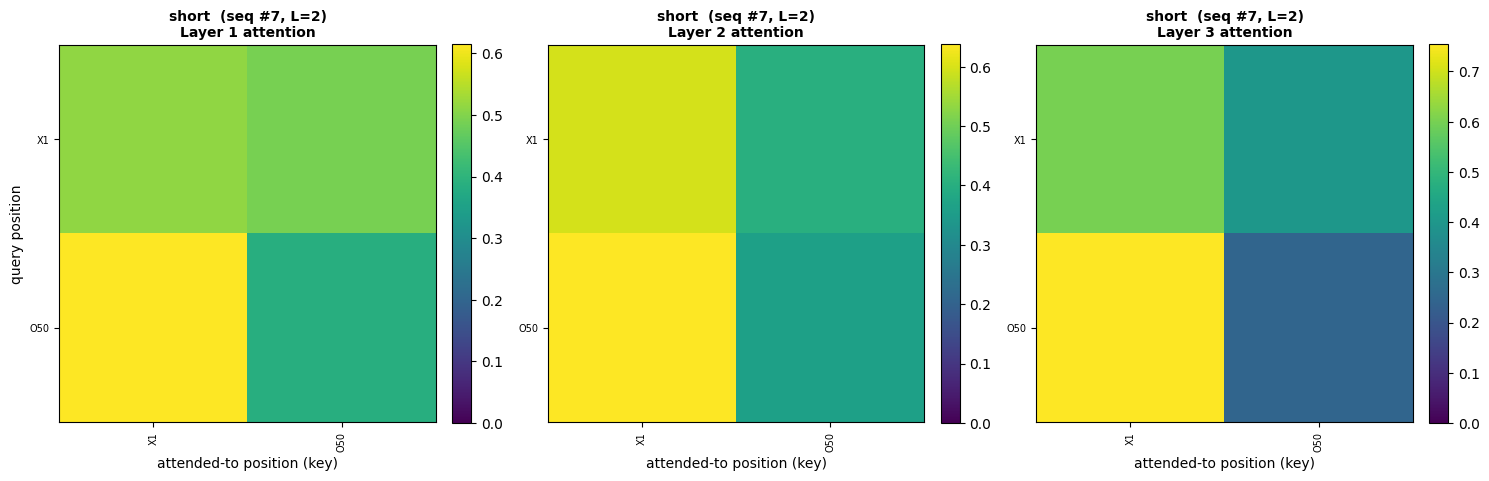


short  -  seq #7  -  length 2
  True        : X1 O50
  Transformer : [O50] O50
  ResNet      : [D46] [D1]


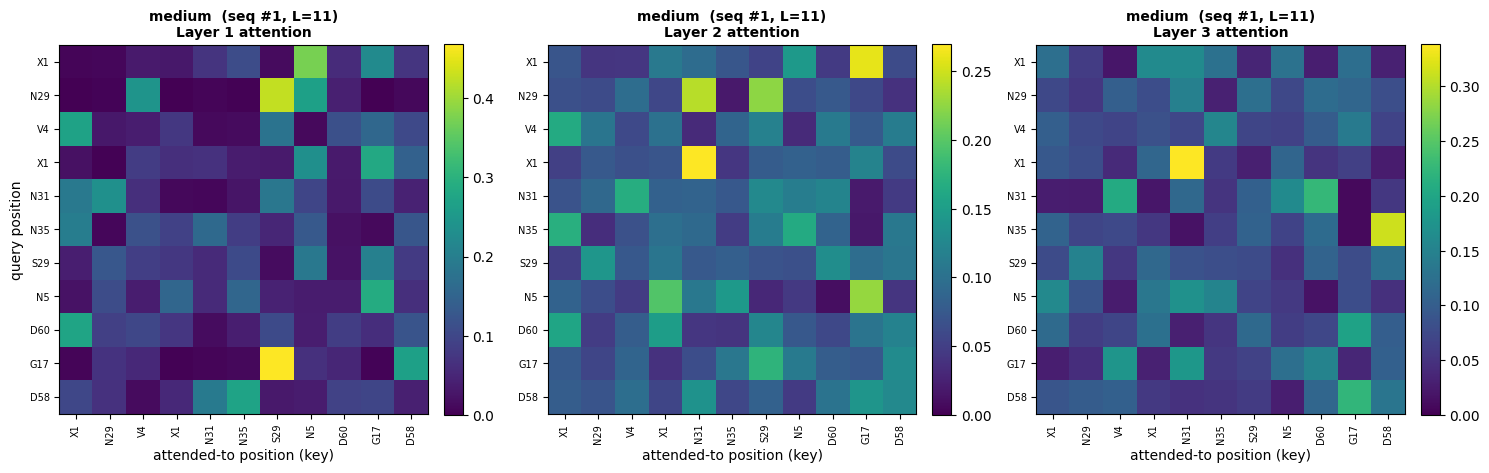


medium  -  seq #1  -  length 11
  True        : X1 N29 V4 X1 N31 N35 S29 N5 D60 G17 D58
  Transformer : X1 N29 V4 X1 N31 N35 S29 N5 [D58] G17 [M17]
  ResNet      : X1 N29 V4 [V1] N31 [D54] S29 N5 [D58] [G1] [F12]


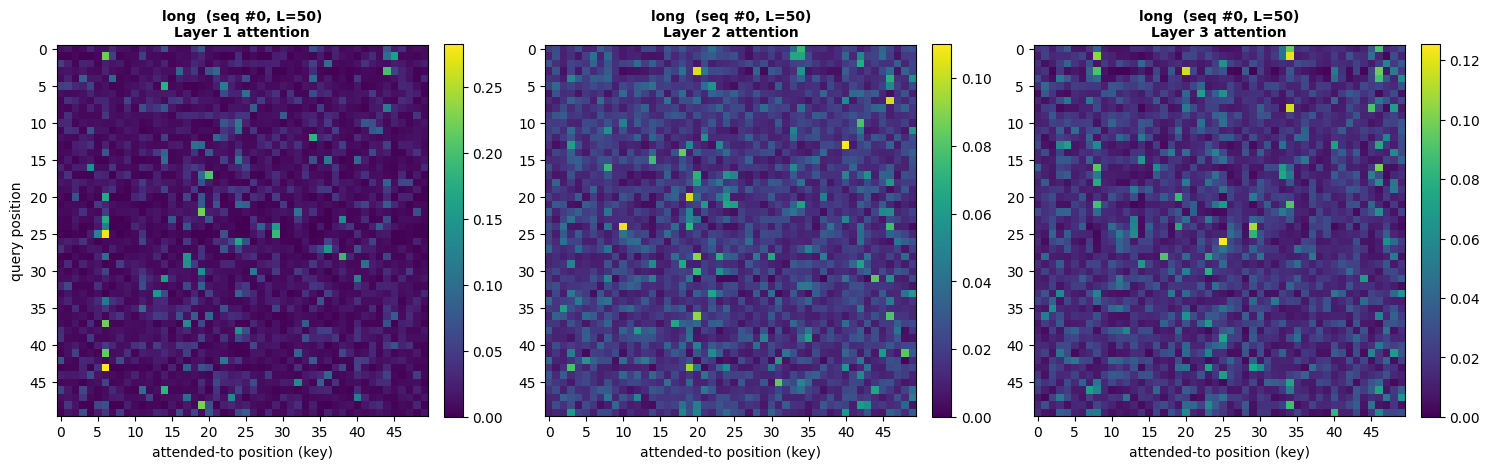


long  -  seq #0  -  length 50
  True        : N1 E34 S29 D46 N35 R8 R8 X1 D21 M17 S29 S29 S29 W24 D1 S29 V31 G39 AA15 S29 G17 E34 F13 G17 G1 G35 M17 S29 G43 Z1 G43 Q1 M17 D21 N37 R8 D36 G43 S29 S29 X1 D36 S29 G17 M17 N37 D46 Z1 G43 X1
  Transformer : [O34] E34 S29 [X1] N35 R8 R8 X1 D21 M17 S29 [M17] S29 [O50] [X1] S29 V31 G39 [X1] [Z1] G17 E34 F13 G17 G1 [G1] M17 S29 [G17] [M17] G43 Q1 M17 D21 N37 [M17] [I9] [G17] S29 S29 X1 D36 S29 G17 M17 N37 [N1] Z1 G43 X1
  ResNet      : [N36] [V13] [M44] [X1] [N33] R8 R8 X1 [N37] [M44] [Z4] [F1] [Z1] W24 [V20] S29 [N36] G39 [X1] [Z4] G17 E34 F13 G17 G1 [G1] [Z1] [P8] [G14] [Z4] [G17] [Z1] [M18] D21 N37 [N37] [X1] [G17] S29 S29 X1 [D58] [M44] [G5] [D28] N37 [N36] Z1 G43 X1


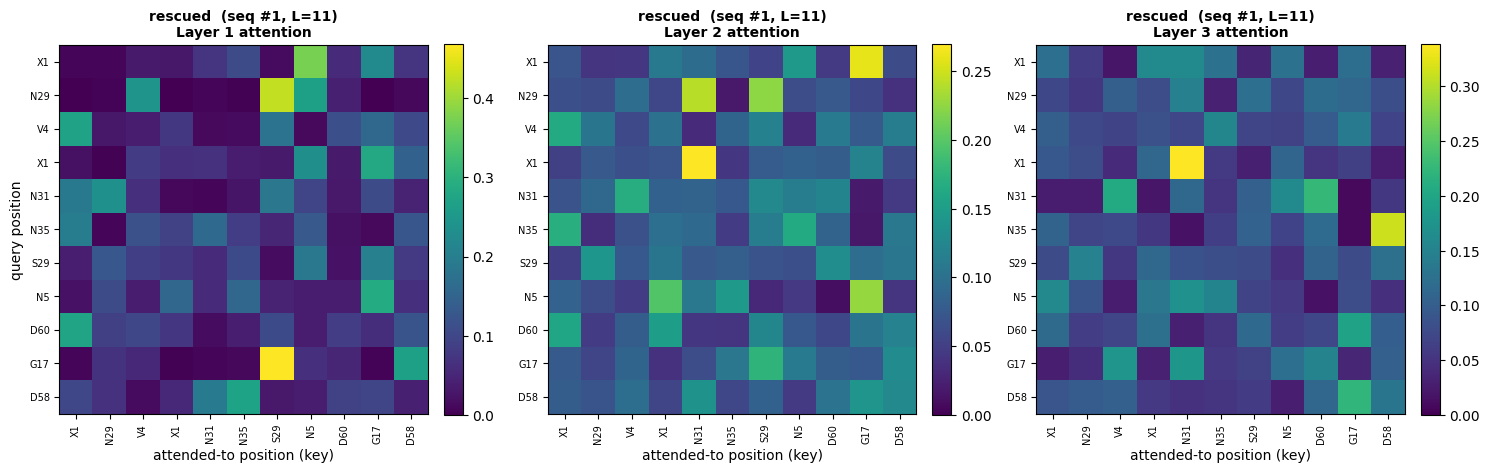


rescued  -  seq #1  -  length 11
  True        : X1 N29 V4 X1 N31 N35 S29 N5 D60 G17 D58
  Transformer : X1 N29 V4 X1 N31 N35 S29 N5 [D58] G17 [M17]
  ResNet      : X1 N29 V4 [V1] N31 [D54] S29 N5 [D58] [G1] [F12]


In [79]:
@torch.no_grad()
def get_attn_for_seq(s_idx):
    feats, labels, mask, L = test_ds[s_idx]
    feats = feats.unsqueeze(0).to(DEVICE)
    mask  = mask.unsqueeze(0).to(DEVICE)
    logits, attns = transformer.forward_with_attn(feats, src_key_padding_mask=mask)
    preds = logits.argmax(-1)[0, :L].cpu().tolist()
    truth = labels[:L].cpu().tolist()
    cropped = [a[0, :L, :L].numpy() for a in attns]
    return cropped, preds, truth

def plot_attn_for_seq(name, s_idx, save_path):
    attns, preds, truth = get_attn_for_seq(s_idx)
    L = len(truth)
    res_pred = res_per_seq_preds[s_idx]
    truth_g  = [idx_to_label.get(c, f'#{c}') for c in truth]
    trf_g    = [idx_to_label.get(c, f'#{c}') for c in preds]
    res_g    = [idx_to_label.get(c, f'#{c}') for c in res_pred]

    fig, axes = plt.subplots(1, len(attns), figsize=(5 * len(attns), 5.0))
    if len(attns) == 1: axes = [axes]
    for li, (ax, A) in enumerate(zip(axes, attns)):
        im = ax.imshow(A, cmap='viridis', aspect='equal', vmin=0)
        ax.set_title(f'{name}  (seq #{s_idx}, L={L})\nLayer {li+1} attention',
                     fontsize=10, fontweight='bold')
        if L <= 16:
            ax.set_xticks(range(L)); ax.set_xticklabels(truth_g, rotation=90, fontsize=7)
            ax.set_yticks(range(L)); ax.set_yticklabels(truth_g, fontsize=7)
        else:
            ax.set_xticks(range(0, L, max(1, L//10)))
            ax.set_yticks(range(0, L, max(1, L//10)))
        ax.set_xlabel('attended-to position (key)')
        if li == 0: ax.set_ylabel('query position')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()

    print(f'\n{name}  -  seq #{s_idx}  -  length {L}')
    print(f'  True        : {" ".join(truth_g)}')
    marked_t = [g if g == truth_g[i] else f'[{g}]' for i, g in enumerate(trf_g)]
    marked_r = [g if g == truth_g[i] else f'[{g}]' for i, g in enumerate(res_g)]
    print(f'  Transformer : {" ".join(marked_t)}')
    print(f'  ResNet      : {" ".join(marked_r)}')

for name, sidx in picks.items():
    plot_attn_for_seq(name, sidx, f'd4e_h2_attn_{name}.png')


# **<span style="color: #c9a84c;">𓆣 Section 14 - Summary Dashboard</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">One figure summarising the comparison story: aggregate metrics, rare-class lift, length-binned sequence accuracy, and the win-set.</span>


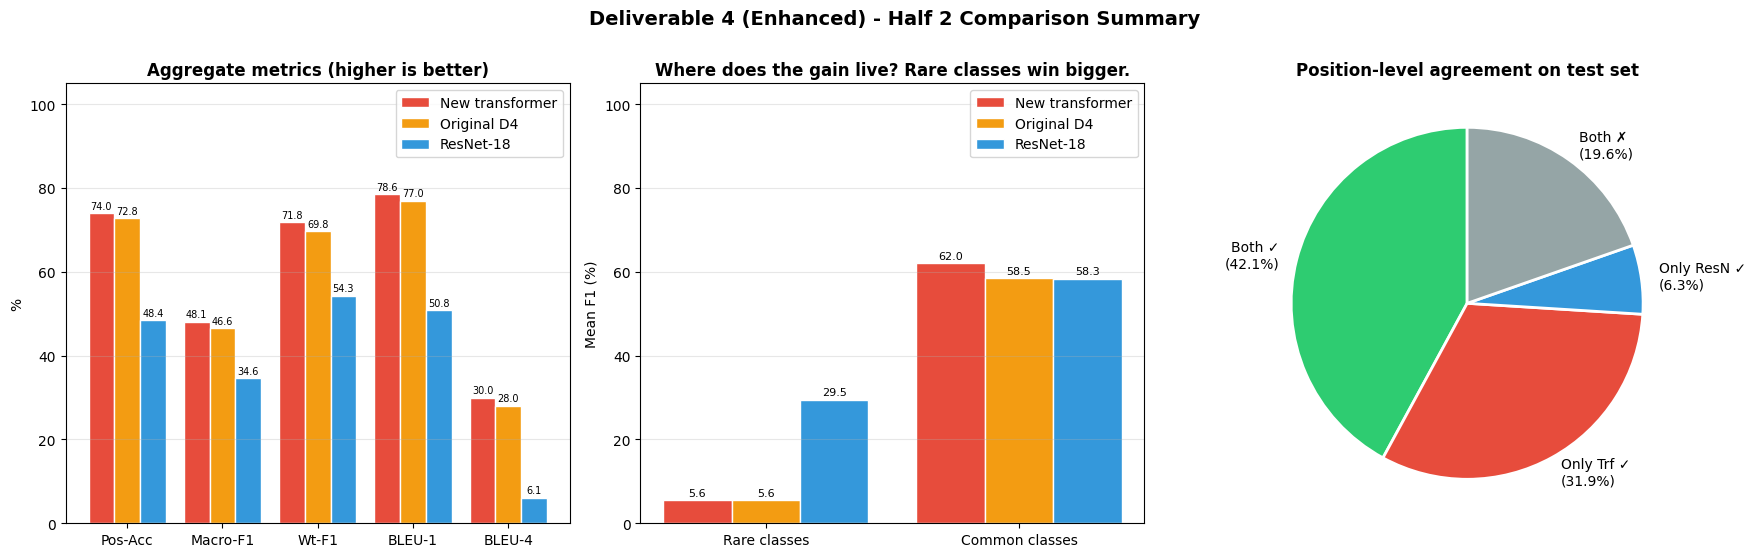

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# (a) Aggregate metrics
ax = axes[0]
metrics = ['Pos-Acc', 'Macro-F1', 'Wt-F1', 'BLEU-1', 'BLEU-4']
trf_v = [pos_acc, macro_f1, weighted_f1, bleu_trf['bleu_1'], bleu_trf['bleu_4']]
d4_v  = [d4_pos_acc, d4_macro_f1, d4_weighted_f1, bleu_d4['bleu_1'], bleu_d4['bleu_4']]
res_v = [res_pos_acc, res_macro_f1, res_weighted_f1, bleu_res['bleu_1'], bleu_res['bleu_4']]
x = np.arange(len(metrics)); w = 0.27
ax.bar(x - w, [v*100 for v in trf_v], w, label='New transformer', color='#e74c3c', edgecolor='white')
ax.bar(x,     [v*100 for v in d4_v],  w, label='Original D4',     color='#f39c12', edgecolor='white')
ax.bar(x + w, [v*100 for v in res_v], w, label='ResNet-18',       color='#3498db', edgecolor='white')
for i, (a, d, b) in enumerate(zip(trf_v, d4_v, res_v)):
    ax.text(i - w, a*100 + 1, f'{a*100:.1f}', ha='center', fontsize=7)
    ax.text(i,     d*100 + 1, f'{d*100:.1f}', ha='center', fontsize=7)
    ax.text(i + w, b*100 + 1, f'{b*100:.1f}', ha='center', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel('%'); ax.set_ylim(0, 105)
ax.set_title('Aggregate metrics (higher is better)', fontweight='bold')
ax.legend(); ax.grid(alpha=.3, axis='y')

# (b) Rare vs common F1
ax = axes[1]
groups = ['Rare classes', 'Common classes']
trf_g  = [rare_df.trf_f1.mean(), common_df.trf_f1.mean()]
d4_g   = [rare_df.d4_f1.mean(),  common_df.d4_f1.mean()]
res_g  = [rare_df.res_f1.mean(), common_df.res_f1.mean()]
x = np.arange(len(groups))
ax.bar(x - w, [v*100 for v in trf_g], w, label='New transformer', color='#e74c3c', edgecolor='white')
ax.bar(x,     [v*100 for v in d4_g],  w, label='Original D4',     color='#f39c12', edgecolor='white')
ax.bar(x + w, [v*100 for v in res_g], w, label='ResNet-18',       color='#3498db', edgecolor='white')
for i, (a, d, b) in enumerate(zip(trf_g, d4_g, res_g)):
    ax.text(i - w, a*100 + 1, f'{a*100:.1f}', ha='center', fontsize=8)
    ax.text(i,     d*100 + 1, f'{d*100:.1f}', ha='center', fontsize=8)
    ax.text(i + w, b*100 + 1, f'{b*100:.1f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(groups)
ax.set_ylabel('Mean F1 (%)'); ax.set_ylim(0, 105)
ax.set_title('Where does the gain live? Rare classes win bigger.', fontweight='bold')
ax.legend(); ax.grid(alpha=.3, axis='y')


# (c) Win-set pie
ax = axes[2]
sizes  = [n_both_ok, n_only_trf, n_only_res, n_both_wrong]
labels = [f'Both ✓\n({n_both_ok/n_total*100:.1f}%)',
          f'Only Trf ✓\n({n_only_trf/n_total*100:.1f}%)',
          f'Only ResN ✓\n({n_only_res/n_total*100:.1f}%)',
          f'Both ✗\n({n_both_wrong/n_total*100:.1f}%)']
colors = ['#2ecc71', '#e74c3c', '#3498db', '#95a5a6']
ax.pie(sizes, labels=labels, colors=colors, startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2},
       textprops={'fontsize': 10})
ax.set_title('Position-level agreement on test set', fontweight='bold')

plt.suptitle('Deliverable 4 (Enhanced) - Half 2 Comparison Summary',
             fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('d4e_h2_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


# **<span style="color: #c9a84c;">𓀀 Section 15 - Save Artifacts</span>**

In [81]:
SAVE_DIR = Path('/kaggle/working')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

torch.save(best_wts, SAVE_DIR / 'transformer_finetuned_best_v2.pth')
per_class_df.to_csv(SAVE_DIR / 'd4e_per_class_metrics.csv', index=False)

d4e_results = {
    'model'             : 'CNN + Transformer (D4 Enhanced: lower LR + LLRD + WD + LS + balanced sampling)',
    'dataset'           : 'Glyph2025 sequences (Franken reading order)',
    'num_classes'       : NUM_CLASSES,

    # Hyperparams used
    'half1_hyperparams' : {
        'lr_stage_a'    : LR_A,
        'lr_stage_b'    : LR_B,
        'wd_stage_a'    : WD_A,
        'wd_stage_b'    : WD_B,
        'label_smooth'  : LS_B,
        'llrd_decay'    : LLRD,
        'balanced_sampling' : True,
    },

    # Half 1 aggregate metrics (transformer, fine-tuned)
    'stage_a_best_val'   : float(best_val_a),
    'stage_b_best_val'   : float(best_val_b),
    'per_position_acc'   : float(pos_acc),
    'sequence_acc_strict': float(seq_acc),
    'macro_f1'           : float(macro_f1),
    'weighted_f1'        : float(weighted_f1),
    'macro_precision'    : float(macro_prec),
    'macro_recall'       : float(macro_rec),

    # ResNet on the same sequences
    'resnet_per_position_acc' : float(res_pos_acc),
    'resnet_sequence_acc'     : float(res_seq_acc),
    'resnet_macro_f1'         : float(res_macro_f1),
    'resnet_weighted_f1'      : float(res_weighted_f1),

    # Original D4 on the same sequences (apples-to-apples re-eval)
    'd4_per_position_acc'     : float(d4_pos_acc),
    'd4_sequence_acc'         : float(d4_seq_acc),
    'd4_macro_f1'             : float(d4_macro_f1),
    'd4_weighted_f1'          : float(d4_weighted_f1),
    'd4_results_json_pos_acc' : float(d4['per_position_acc']),  # for reference
    'delta_new_vs_d4_re_eval' : float(pos_acc - d4_pos_acc),

    # BLEU
    'bleu_transformer'  : {k: float(v) for k, v in bleu_trf.items()},
    'bleu_d4'           : {k: float(v) for k, v in bleu_d4.items()},
    'bleu_resnet'       : {k: float(v) for k, v in bleu_res.items()},

    # Rare-class breakdown
    'rare_class_threshold'      : float(rare_thr),
    'n_rare'                    : int(len(rare_df)),
    'n_common'                  : int(len(common_df)),
    'rare_mean_f1_transformer'  : float(rare_df.trf_f1.mean()),
    'rare_mean_f1_resnet'       : float(rare_df.res_f1.mean()),
    'common_mean_f1_transformer': float(common_df.trf_f1.mean()),
    'common_mean_f1_resnet'     : float(common_df.res_f1.mean()),
    'share_total_delta_in_rare' : float(rare_delta / total_delta) if total_delta else 0.0,

    # Win set
    'win_only_transformer_positions' : int(n_only_trf),
    'win_only_resnet_positions'      : int(n_only_res),
    'win_only_transformer_sequences' : int(seq_only_trf),
    'win_only_resnet_sequences'      : int(seq_only_res),

    # Length-binned
    'seq_acc_by_length'  : seq_by_len_table,

    # Provenance / deltas
    'phase3_baseline'    : p3['per_position_acc'],
    'delta_vs_phase3'    : float(pos_acc) - p3['per_position_acc'],
    'phase1_baseline'    : p3['phase1_top1'],
    'delta_vs_phase1'    : float(pos_acc) - p3['phase1_top1'],
}

with open(SAVE_DIR / 'd4e_results.json', 'w') as f:
    json.dump(d4e_results, f, indent=2)

print('Files saved:')
for f in sorted(SAVE_DIR.glob('*')):
    if f.is_file():
        print(f'  {f.name}  ({f.stat().st_size/1024:.0f} KB)')

print()
print('=' * 65)
print('  DELIVERABLE 4 (ENHANCED) COMPLETE')
print('=' * 65)
print(f'  Phase 1 baseline (ResNet-18)          : {p3["phase1_top1"]*100:.2f}%')
print(f'  Phase 3 baseline (CNN + Transformer)  : {p3["per_position_acc"]*100:.2f}%')
print(f'  Original D4 (re-eval, same images)    : {d4_pos_acc*100:.2f}%')
print(f'  D4 Enhanced (this notebook)           : {pos_acc*100:.2f}%')
print(f'  Δ vs Phase 3                          : {(pos_acc - p3["per_position_acc"])*100:+.2f}%')
print(f'  Δ vs Original D4 (re-eval)            : {(pos_acc - d4_pos_acc)*100:+.2f}%')
print(f'  Transformer rescues (positions)       : {n_only_trf}')
print(f'  Rare-class share of total ΔF1         : {rare_delta/total_delta*100 if total_delta else 0:.1f}%')
print(f'  BLEU-4 (Trf vs ResNet)                : {bleu_trf["bleu_4"]*100:.2f}% vs {bleu_res["bleu_4"]*100:.2f}%')
print('=' * 65)


Files saved:
  d4e_h1_training_curves.png  (101 KB)
  d4e_h2_attn_long.png  (89 KB)
  d4e_h2_attn_medium.png  (55 KB)
  d4e_h2_attn_rescued.png  (56 KB)
  d4e_h2_attn_short.png  (44 KB)
  d4e_h2_bleu.png  (51 KB)
  d4e_h2_f1_vs_freq.png  (84 KB)
  d4e_h2_per_class_f1.png  (134 KB)
  d4e_h2_per_seq_acc_by_length.png  (58 KB)
  d4e_h2_seq_acc_by_length.png  (96 KB)
  d4e_h2_summary_dashboard.png  (128 KB)
  d4e_h2_winset.png  (79 KB)
  d4e_h2_winset_pie_per_seq.png  (143 KB)
  d4e_per_class_metrics.csv  (9 KB)
  d4e_results.json  (4 KB)
  transformer_finetuned_best_v2.pth  (6932 KB)

  DELIVERABLE 4 (ENHANCED) COMPLETE
  Phase 1 baseline (ResNet-18)          : 66.72%
  Phase 3 baseline (CNN + Transformer)  : 73.51%
  Original D4 (re-eval, same images)    : 72.82%
  D4 Enhanced (this notebook)           : 74.01%
  Δ vs Phase 3                          : +0.50%
  Δ vs Original D4 (re-eval)            : +1.19%
  Transformer rescues (positions)       : 161
  Rare-class share of total ΔF1    